Ejecutando simulación...
Progreso: 10/50 filas completadas
Progreso: 20/50 filas completadas
Progreso: 30/50 filas completadas
Progreso: 40/50 filas completadas
Progreso: 50/50 filas completadas


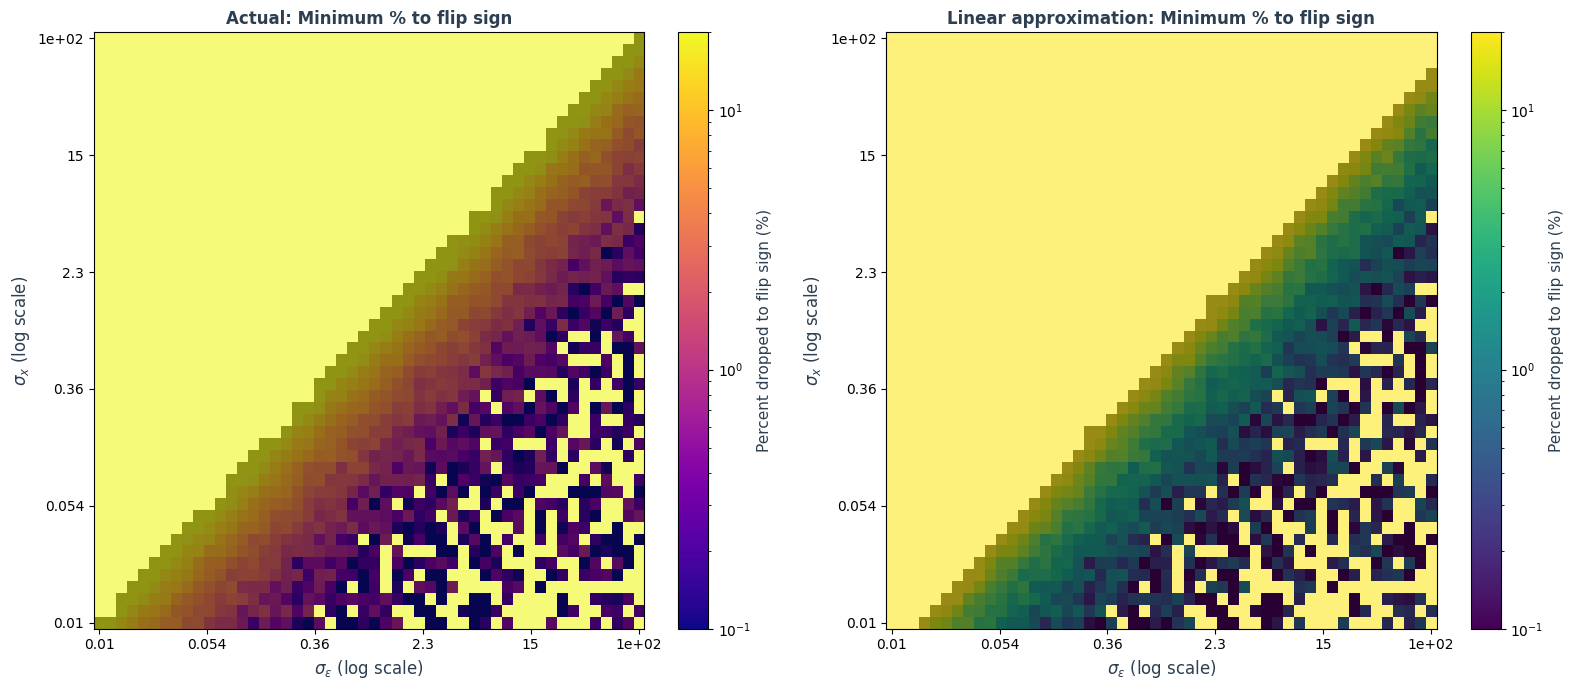

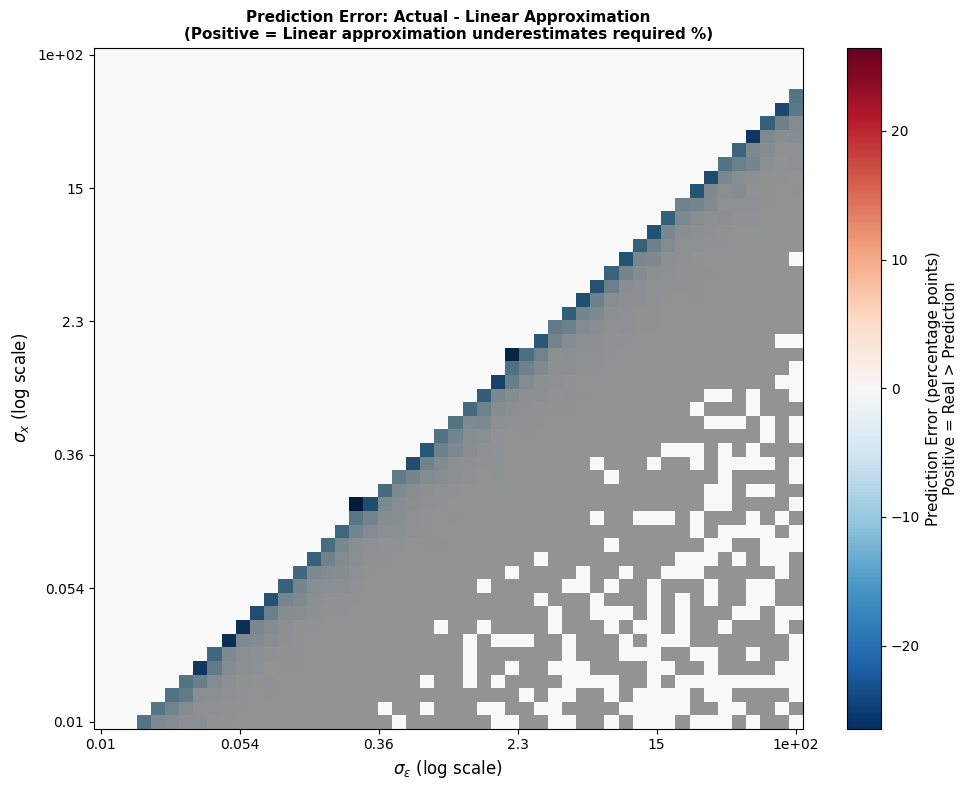

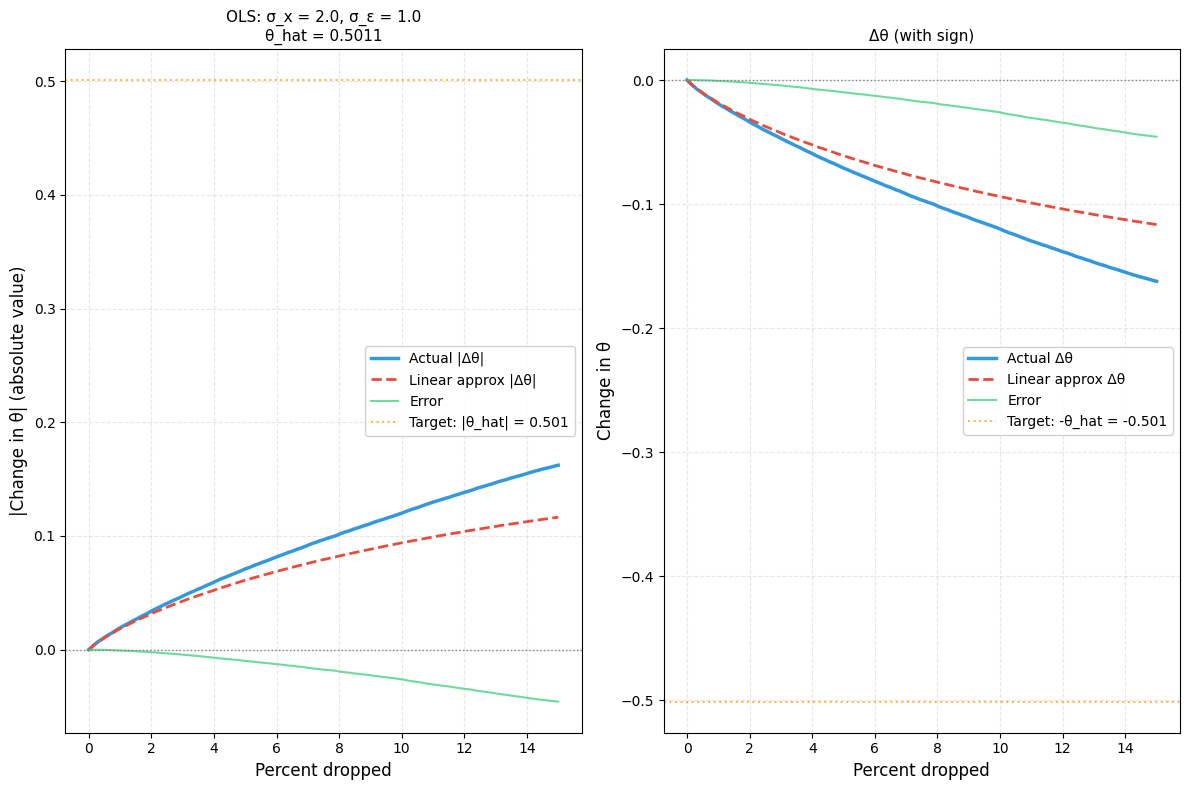

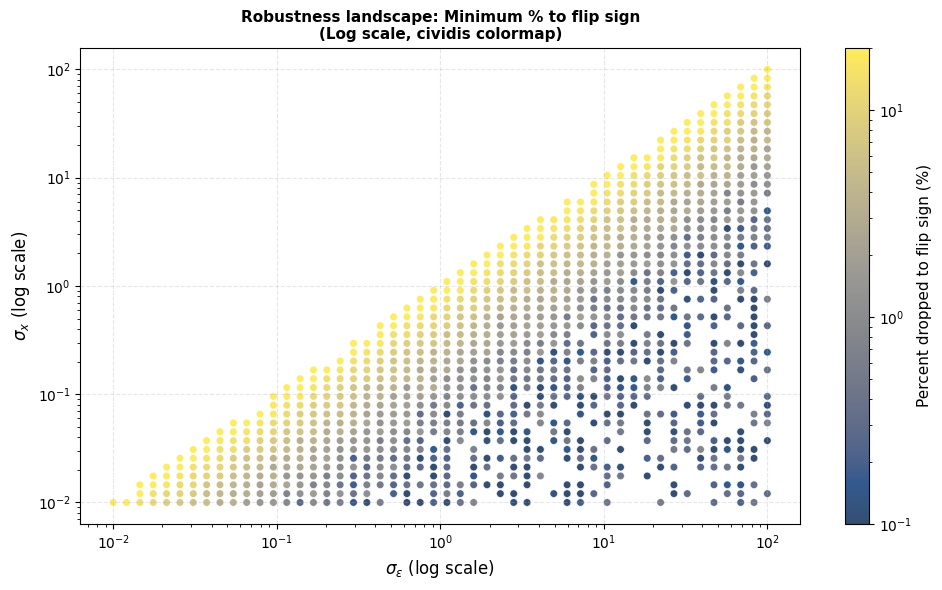


ANÁLISIS PARA σ_x = 2.0, σ_ε = 1.0
θ_hat original: 0.501066
|θ_hat|: 0.501066
Signo de θ_hat: positivo

Para cambiar el signo, necesitamos Δθ ≤ -0.501066

──────────────────────────────────────────────────────────────────────
ESTADÍSTICAS DE ψ:
  ├─ Media: -8.847090e-21
  ├─ Desviación estándar: 1.014030e-04
  ├─ Mínimo: -6.741387e-04
  ├─ Máximo: 6.839078e-04
  ├─ Suma total: -4.423545e-17 (debería ser ~0)
  └─ Rango: 1.358046e-03

──────────────────────────────────────────────────────────────────────
COMPARACIÓN EN DIFERENTES PORCENTAJES:
──────────────────────────────────────────────────────────────────────

1% eliminado:
  ├─ Δθ real: -0.003754
  ├─ Σψ acumulado: -0.018529
  └─ Diferencia: 0.014775

2% eliminado:
  ├─ Δθ real: -0.007145
  ├─ Σψ acumulado: -0.031700
  └─ Diferencia: 0.024556

5% eliminado:
  ├─ Δθ real: -0.015031
  ├─ Σψ acumulado: -0.061087
  └─ Diferencia: 0.046056

10% eliminado:
  ├─ Δθ real: -0.026787
  ├─ Σψ acumulado: -0.093981
  └─ Diferencia: 0.067195



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches

np.random.seed(42)

# ======================
# 1. PARÁMETROS
# ======================
N = 5000
theta0 = 0.5

# Escala logarítmica para los sigmas (rango amplio para apreciar mejor)
sigma_x_vals = np.logspace(-2, 2, 50)  # 0.01 a 100
sigma_e_vals = np.logspace(-2, 2, 50)  # 0.01 a 100

percent_to_flip = np.zeros((len(sigma_x_vals), len(sigma_e_vals)))
percent_predicted = np.zeros((len(sigma_x_vals), len(sigma_e_vals)))

# ======================
# 2. FUNCIÓN OLS
# ======================
def ols_theta(x, y, w):
    return np.sum(w * x * y) / np.sum(w * x**2)

# ======================
# 3. SIMULACIÓN HEATMAP
# ======================
print("Ejecutando simulación...")
for i, sx in enumerate(sigma_x_vals):
    for j, se in enumerate(sigma_e_vals):
        
        X = np.random.normal(0, sx, N)
        eps = np.random.normal(0, se, N)
        Y = theta0 * X + eps
        
        theta_hat = ols_theta(X, Y, np.ones(N))
        
        # Calcular residuos y psi
        residuals = Y - theta_hat * X
        Sx = np.mean(X**2)
        
        # Fórmula correcta de psi para OLS
        psi = - (X * residuals) / (N * Sx)
        
        # Ordenar por psi (más negativo primero)
        order = np.argsort(psi)
        
        # BUSCAR MÍNIMO PORCENTAJE PARA CAMBIAR SIGNO (REAL)
        found = False
        for k in range(1, int(0.3 * N)):
            w = np.ones(N)
            w[order[:k]] = 0
            
            theta_new = ols_theta(X, Y, w)
            
            if np.sign(theta_new) != np.sign(theta_hat):
                percent_to_flip[i, j] = k / N * 100
                found = True
                break
        
        if not found:
            percent_to_flip[i, j] = np.nan
        
        # PREDICCIÓN USANDO APROXIMACIÓN LINEAL
        cumsum_psi = np.cumsum(psi[order])
        
        if theta_hat > 0:
            # Necesitamos suma acumulativa <= -theta_hat
            idx = np.where(cumsum_psi <= -theta_hat)[0]
        else:
            # Necesitamos suma acumulativa >= -theta_hat
            idx = np.where(cumsum_psi >= -theta_hat)[0]
        
        if len(idx) > 0:
            percent_predicted[i, j] = (idx[0] + 1) / N * 100
        else:
            percent_predicted[i, j] = np.nan
    
    # Progreso
    if (i + 1) % 10 == 0:
        print(f"Progreso: {i+1}/{len(sigma_x_vals)} filas completadas")

# ======================
# 4. HEATMAP COMPARATIVO CON PALETAS NATURALES
# ======================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: Simulación real - usando plasma (cálido y agradable)
ax1 = axes[0]
mask_nan = np.isnan(percent_to_flip)
data_plot = percent_to_flip.copy()
data_plot[mask_nan] = 100

# Usar plasma - buena para datos con log scale, perceptualmente uniforme
im1 = ax1.imshow(
    data_plot,
    origin='lower',
    aspect='auto',
    cmap='plasma',  # Paleta cálida y natural
    norm=LogNorm(vmin=0.1, vmax=20, clip=True)
)

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Percent dropped to flip sign (%)', fontsize=11)
cbar1.ax.yaxis.label.set_color('#2c3e50')

# Configurar ticks logarítmicos
xticks_idx = np.linspace(0, len(sigma_e_vals)-1, 6)
yticks_idx = np.linspace(0, len(sigma_x_vals)-1, 6)

ax1.set_xticks(xticks_idx)
ax1.set_yticks(yticks_idx)
ax1.set_xticklabels([f"{sigma_e_vals[int(i)]:.2g}" for i in xticks_idx])
ax1.set_yticklabels([f"{sigma_x_vals[int(i)]:.2g}" for i in yticks_idx])

ax1.set_xlabel(r'$\sigma_\varepsilon$ (log scale)', fontsize=12, color='#2c3e50')
ax1.set_ylabel(r'$\sigma_x$ (log scale)', fontsize=12, color='#2c3e50')
ax1.set_title('Actual: Minimum % to flip sign', fontsize=12, fontweight='bold', color='#2c3e50')

# Áreas NA en gris suave
ax1.imshow(mask_nan, cmap='gray', alpha=0.4, origin='lower', aspect='auto')

# Panel derecho: Predicción lineal - usando viridis (moderna y accesible)
ax2 = axes[1]
mask_nan_pred = np.isnan(percent_predicted)
data_plot_pred = percent_predicted.copy()
data_plot_pred[mask_nan_pred] = 100

im2 = ax2.imshow(
    data_plot_pred,
    origin='lower',
    aspect='auto',
    cmap='viridis',  # Paleta moderna, accesible para daltónicos
    norm=LogNorm(vmin=0.1, vmax=20, clip=True)
)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Percent dropped to flip sign (%)', fontsize=11)
cbar2.ax.yaxis.label.set_color('#2c3e50')

ax2.set_xticks(xticks_idx)
ax2.set_yticks(yticks_idx)
ax2.set_xticklabels([f"{sigma_e_vals[int(i)]:.2g}" for i in xticks_idx])
ax2.set_yticklabels([f"{sigma_x_vals[int(i)]:.2g}" for i in yticks_idx])

ax2.set_xlabel(r'$\sigma_\varepsilon$ (log scale)', fontsize=12, color='#2c3e50')
ax2.set_ylabel(r'$\sigma_x$ (log scale)', fontsize=12, color='#2c3e50')
ax2.set_title('Linear approximation: Minimum % to flip sign', fontsize=12, fontweight='bold', color='#2c3e50')

ax2.imshow(mask_nan_pred, cmap='gray', alpha=0.4, origin='lower', aspect='auto')

plt.tight_layout()
plt.show()

# ======================
# 5. HEATMAP DE ERROR CON PALETA DIVERGENTE SUAVE
# ======================
plt.figure(figsize=(10, 8))

# Calcular diferencia (error de predicción)
error_prediction = percent_to_flip - percent_predicted

mask_error = np.isnan(error_prediction)
error_plot = error_prediction.copy()
error_plot[mask_error] = 0

# Usar paleta RdBu_r (rojo-azul) pero con transición más suave
max_abs_error = np.nanmax(np.abs(error_prediction))
vmax_error = max(10, max_abs_error)

im_error = plt.imshow(
    error_plot,
    origin='lower',
    aspect='auto',
    cmap='RdBu_r',  # Paleta divergente para errores
    vmin=-vmax_error,
    vmax=vmax_error
)

cbar = plt.colorbar(im_error)
cbar.set_label('Prediction Error (percentage points)\nPositive = Real > Prediction', fontsize=11)

xticks_idx = np.linspace(0, len(sigma_e_vals)-1, 6)
yticks_idx = np.linspace(0, len(sigma_x_vals)-1, 6)

plt.xticks(xticks_idx, [f"{sigma_e_vals[int(i)]:.2g}" for i in xticks_idx])
plt.yticks(yticks_idx, [f"{sigma_x_vals[int(i)]:.2g}" for i in yticks_idx])

plt.xlabel(r'$\sigma_\varepsilon$ (log scale)', fontsize=12)
plt.ylabel(r'$\sigma_x$ (log scale)', fontsize=12)
plt.title('Prediction Error: Actual - Linear Approximation\n(Positive = Linear approximation underestimates required %)', 
          fontsize=11, fontweight='bold')

plt.imshow(mask_error, cmap='gray', alpha=0.4, origin='lower', aspect='auto')

plt.tight_layout()
plt.show()

# ======================
# 6. GRÁFICO DE LÍNEAS CON PALETA MEJORADA
# ======================
plt.figure(figsize=(12, 8))

# Colores más agradables
colors = {
    'actual': '#3498db',      # Azul suave
    'approx': '#e74c3c',      # Rojo suave
    'error': '#2ecc71',       # Verde
    'target': '#f39c12',      # Naranja
    'flip': '#9b59b6'         # Púrpura
}

sx = 2.0
se = 1.0

# Generar datos
np.random.seed(123)

X = np.random.normal(0, sx, N)
eps = np.random.normal(0, se, N)
Y = theta0 * X + eps

theta_hat = ols_theta(X, Y, np.ones(N))

residuals = Y - theta_hat * X
Sx = np.mean(X**2)
psi = - (X * residuals) / (N * Sx)

order = np.argsort(psi)

# Probar diferentes fracciones
fractions = np.linspace(0, 0.15, 100)

theta_real = []
theta_pred = []
errors = []

for f in fractions:
    k = int(f * N)
    
    # Cambio real
    w = np.ones(N)
    if k > 0:
        w[order[:k]] = 0
    theta_new = ols_theta(X, Y, w)
    change_real = theta_new - theta_hat
    
    # Predicción: suma acumulativa de psi
    if k > 0:
        cumsum_psi = np.sum(psi[order[:k]])
    else:
        cumsum_psi = 0
    
    change_pred = cumsum_psi
    
    theta_real.append(change_real)
    theta_pred.append(change_pred)
    errors.append(change_real - change_pred)

# Convertir a arrays
theta_real = np.array(theta_real)
theta_pred = np.array(theta_pred)
errors = np.array(errors)

# Primer subplot: Valor absoluto
plt.subplot(1, 2, 1)

plt.plot(fractions*100, np.abs(theta_real), color=colors['actual'], 
         linewidth=2.5, label='Actual |Δθ|')
plt.plot(fractions*100, np.abs(theta_pred), color=colors['approx'], 
         linestyle='--', linewidth=2, label='Linear approx |Δθ|')
plt.plot(fractions*100, errors, color=colors['error'], 
         linewidth=1.5, label='Error', alpha=0.7)

plt.axhline(0, linestyle=':', color='gray', linewidth=1)
plt.axhline(np.abs(theta_hat), linestyle=':', color=colors['target'], alpha=0.7, 
            label=f'Target: |θ_hat| = {np.abs(theta_hat):.3f}')

plt.xlabel('Percent dropped', fontsize=12)
plt.ylabel('|Change in θ| (absolute value)', fontsize=12)
plt.title(f'OLS: σ_x = {sx}, σ_ε = {se}\nθ_hat = {theta_hat:.4f}', fontsize=11)

plt.legend(loc='best', framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')

# Encontrar el punto donde se flipa el signo
for i, change in enumerate(theta_real):
    if theta_hat + change <= 0:
        plt.axvline(fractions[i]*100, linestyle='--', color=colors['flip'], alpha=0.7)
        plt.text(fractions[i]*100 + 0.5, np.abs(theta_hat)/2, 
                f'Flip at {fractions[i]*100:.1f}%', 
                fontsize=9, rotation=90, color=colors['flip'])
        break

# Segundo subplot: cambio real con signo
plt.subplot(1, 2, 2)

plt.plot(fractions*100, theta_real, color=colors['actual'], 
         linewidth=2.5, label='Actual Δθ')
plt.plot(fractions*100, theta_pred, color=colors['approx'], 
         linestyle='--', linewidth=2, label='Linear approx Δθ')
plt.plot(fractions*100, errors, color=colors['error'], 
         linewidth=1.5, label='Error', alpha=0.7)

plt.axhline(0, linestyle=':', color='gray', linewidth=1)
plt.axhline(-theta_hat, linestyle=':', color=colors['target'], alpha=0.7, 
            label=f'Target: -θ_hat = {-theta_hat:.3f}')

plt.xlabel('Percent dropped', fontsize=12)
plt.ylabel('Change in θ', fontsize=12)
plt.title(f'Δθ (with sign)', fontsize=11)

plt.legend(loc='best', framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ======================
# 7. GRÁFICO ADICIONAL CON PALETA CIVIDIS (ACCESIBLE)
# ======================
plt.figure(figsize=(10, 6))

# Crear un scatter plot de la relación entre sigma_x y sigma_e con colores basados en el porcentaje
valid_idx = ~mask_nan
X_grid, Y_grid = np.meshgrid(sigma_e_vals, sigma_x_vals)

plt.scatter(
    X_grid[valid_idx], 
    Y_grid[valid_idx], 
    c=percent_to_flip[valid_idx],
    cmap='cividis',  # Paleta accesible para daltónicos
    norm=LogNorm(vmin=0.1, vmax=20),
    s=30,
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar()
cbar.set_label('Percent dropped to flip sign (%)', fontsize=11)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\sigma_\varepsilon$ (log scale)', fontsize=12)
plt.ylabel(r'$\sigma_x$ (log scale)', fontsize=12)
plt.title('Robustness landscape: Minimum % to flip sign\n(Log scale, cividis colormap)', 
          fontsize=11, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ======================
# 8. ESTADÍSTICAS DETALLADAS
# ======================
print(f"\n{'='*70}")
print(f"ANÁLISIS PARA σ_x = {sx}, σ_ε = {se}")
print(f"{'='*70}")
print(f"θ_hat original: {theta_hat:.6f}")
print(f"|θ_hat|: {np.abs(theta_hat):.6f}")
print(f"Signo de θ_hat: {'positivo' if theta_hat > 0 else 'negativo'}")

print(f"\nPara cambiar el signo, necesitamos Δθ {'≤' if theta_hat > 0 else '≥'} {-theta_hat:.6f}")

# Encontrar el punto exacto donde se flipa
for i in range(len(fractions)):
    if theta_hat + theta_real[i] <= 0:
        flip_percent = fractions[i] * 100
        flip_k = int(fractions[i] * N)
        print(f"\n{'─'*70}")
        print(f"PUNTO DONDE SE FLIPA EL SIGNO:")
        print(f"  ├─ Porcentaje eliminado: {flip_percent:.2f}%")
        print(f"  ├─ Número de puntos: {flip_k}")
        print(f"  ├─ Δθ real: {theta_real[i]:.6f}")
        print(f"  ├─ Δθ predicho (acumulado ψ): {theta_pred[i]:.6f}")
        print(f"  ├─ Error absoluto: {errors[i]:.6f}")
        print(f"  └─ Error relativo: {abs(errors[i]/theta_real[i])*100:.2f}%")
        break

print(f"\n{'─'*70}")
print(f"ESTADÍSTICAS DE ψ:")
print(f"  ├─ Media: {np.mean(psi):.6e}")
print(f"  ├─ Desviación estándar: {np.std(psi):.6e}")
print(f"  ├─ Mínimo: {np.min(psi):.6e}")
print(f"  ├─ Máximo: {np.max(psi):.6e}")
print(f"  ├─ Suma total: {np.sum(psi):.6e} (debería ser ~0)")
print(f"  └─ Rango: {np.max(psi) - np.min(psi):.6e}")

# Comparación entre real y predicho en diferentes percentiles
print(f"\n{'─'*70}")
print(f"COMPARACIÓN EN DIFERENTES PORCENTAJES:")
print(f"{'─'*70}")
for pct in [1, 2, 5, 10]:
    idx = int(pct/100 * N)
    cumsum_psi_at_pct = np.sum(psi[order[:idx]])
    real_idx = int(pct/100 * 100)  # índice en fractions
    if real_idx < len(theta_real):
        print(f"\n{pct}% eliminado:")
        print(f"  ├─ Δθ real: {theta_real[real_idx]:.6f}")
        print(f"  ├─ Σψ acumulado: {cumsum_psi_at_pct:.6f}")
        print(f"  └─ Diferencia: {theta_real[real_idx] - cumsum_psi_at_pct:.6f}")

print(f"\n{'='*70}")

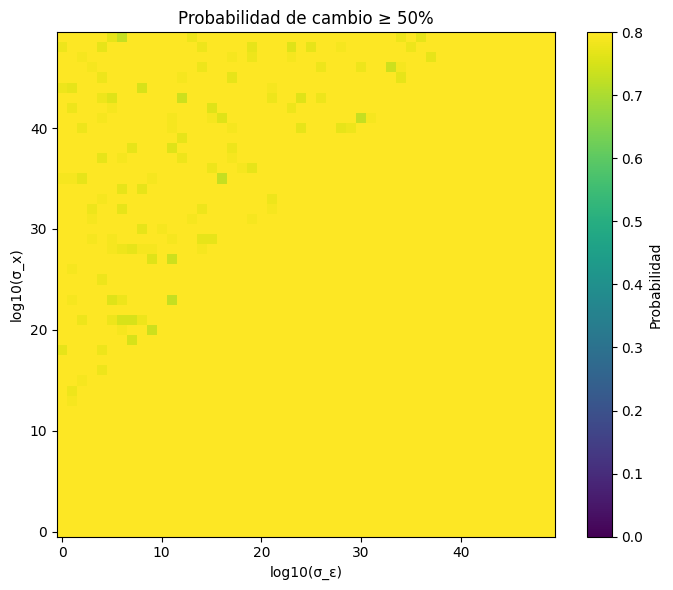

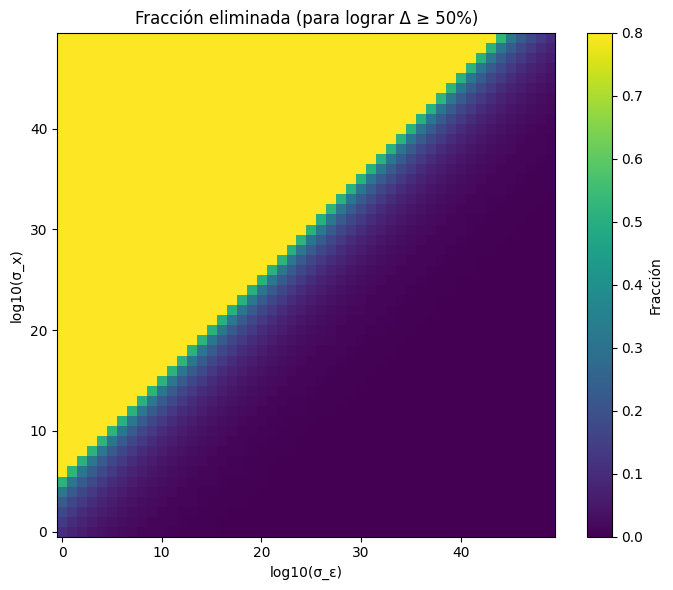


Estadísticas descriptivas de θ
Media: 0.4982
Mediana: 0.5000
Desv. estándar: 9.0795
Varianza: 82.4370
Mínimo: -376.0621
Máximo: 370.1104
P5: -1.0618
P25: 0.4925
P75: 0.5079
P95: 2.0774
Bias: -0.0018
Bias relativo (%): -0.37%

θ condicionado a éxito AMIP
Media: 0.4980
Mediana: 0.5000
Desv. estándar: 9.3488
Bias: -0.0020
Bias (%): -0.39%


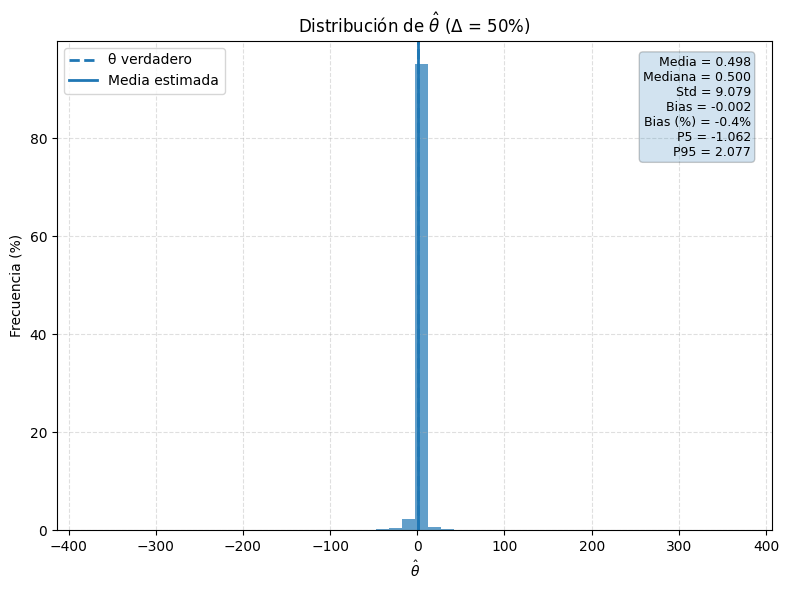

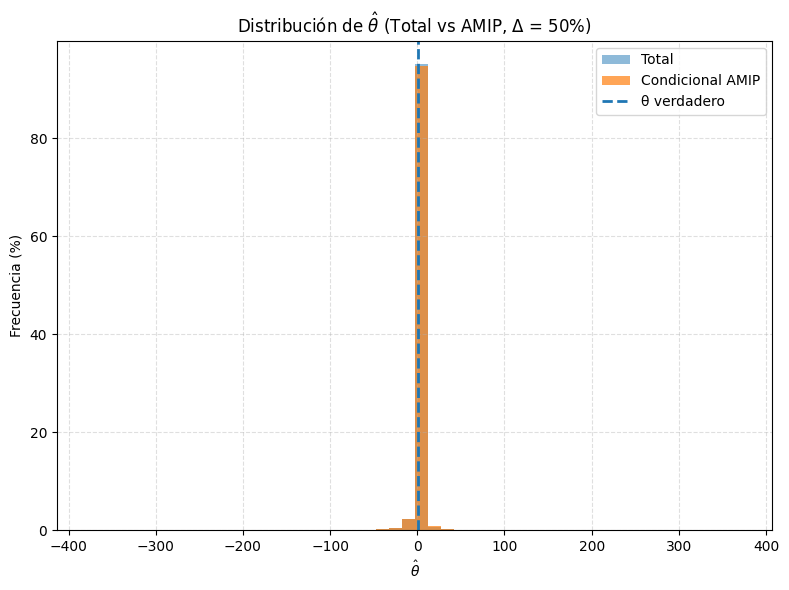

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN #ols 50%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 0.5
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 0.5
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

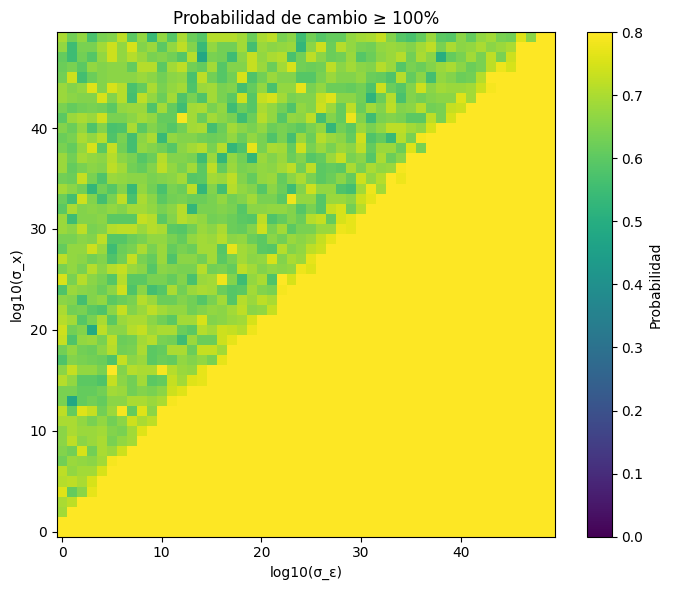

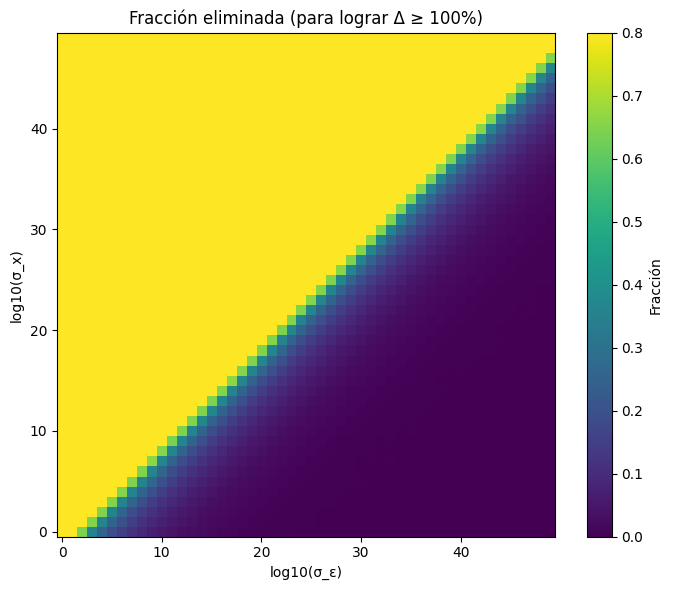


Estadísticas descriptivas de θ
Media: 0.9842
Mediana: 1.0000
Desv. estándar: 9.0821
Varianza: 82.4839
Mínimo: -445.9476
Máximo: 318.3488
P5: -0.5738
P25: 0.9924
P75: 1.0078
P95: 2.5373
Bias: -0.0158
Bias relativo (%): -1.58%

θ condicionado a éxito AMIP
Media: 0.9810
Mediana: 1.0000
Desv. estándar: 9.9418
Bias: -0.0190
Bias (%): -1.90%


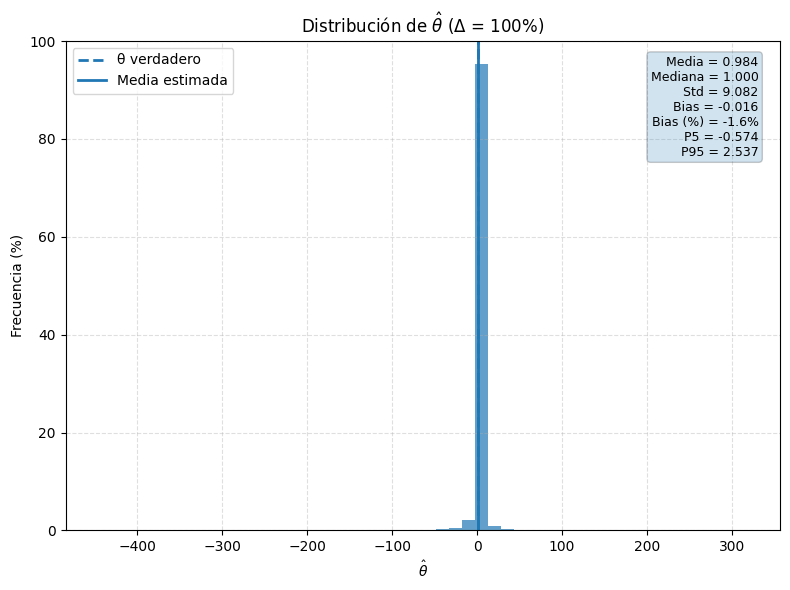

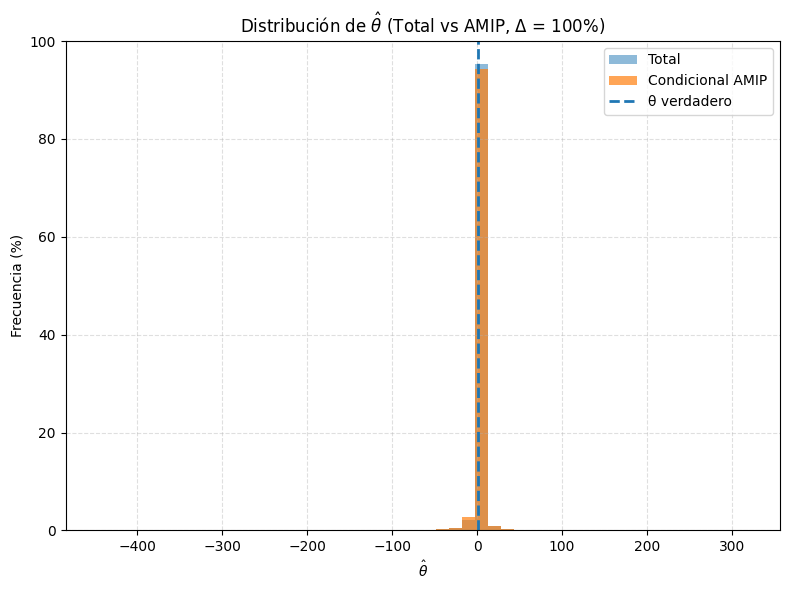

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

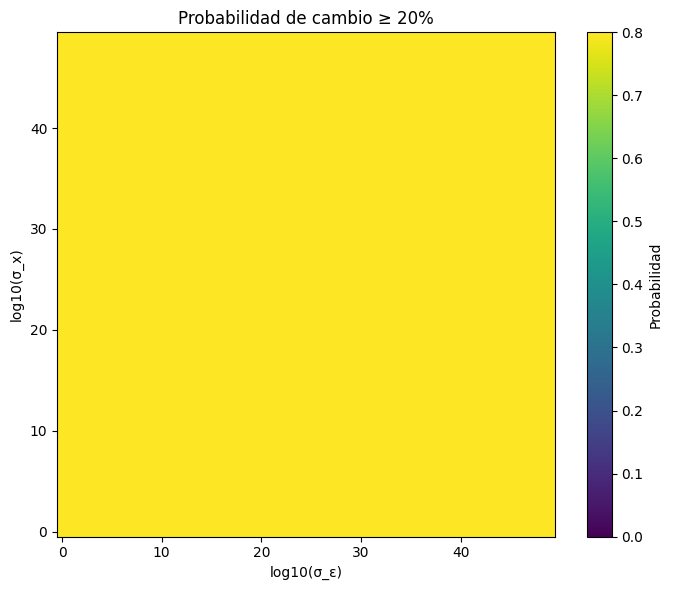

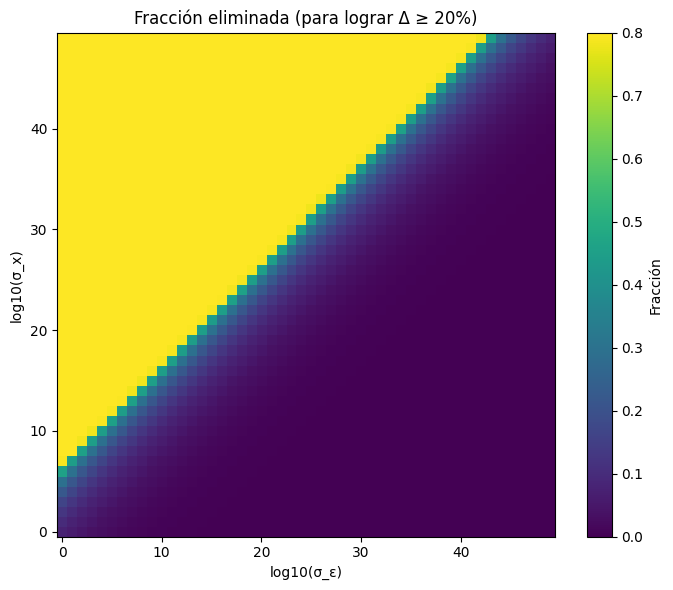


Estadísticas descriptivas de θ
Media: 0.9979
Mediana: 1.0000
Desv. estándar: 8.9660
Varianza: 80.3891
Mínimo: -399.5240
Máximo: 378.3341
P5: -0.5792
P25: 0.9924
P75: 1.0077
P95: 2.5578
Bias: -0.0021
Bias relativo (%): -0.21%

θ condicionado a éxito AMIP
Media: 0.9978
Mediana: 1.0000
Desv. estándar: 9.0629
Bias: -0.0022
Bias (%): -0.22%


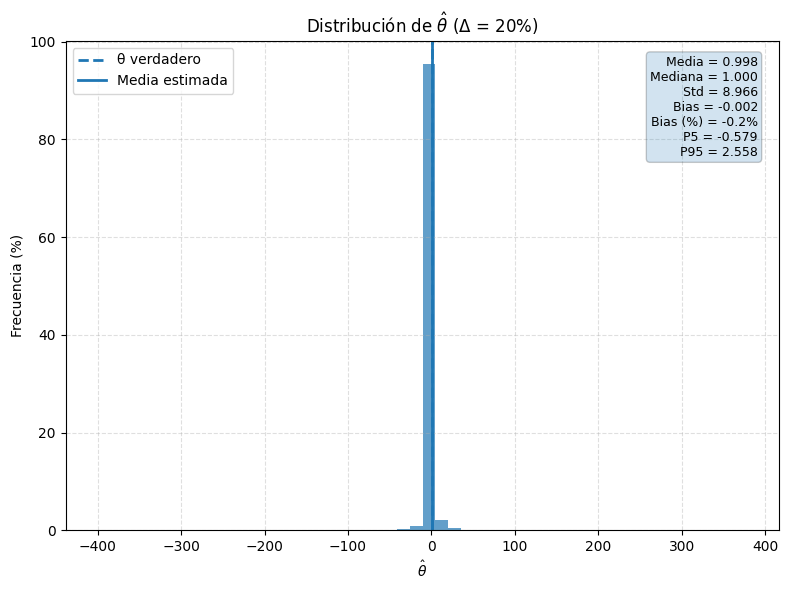

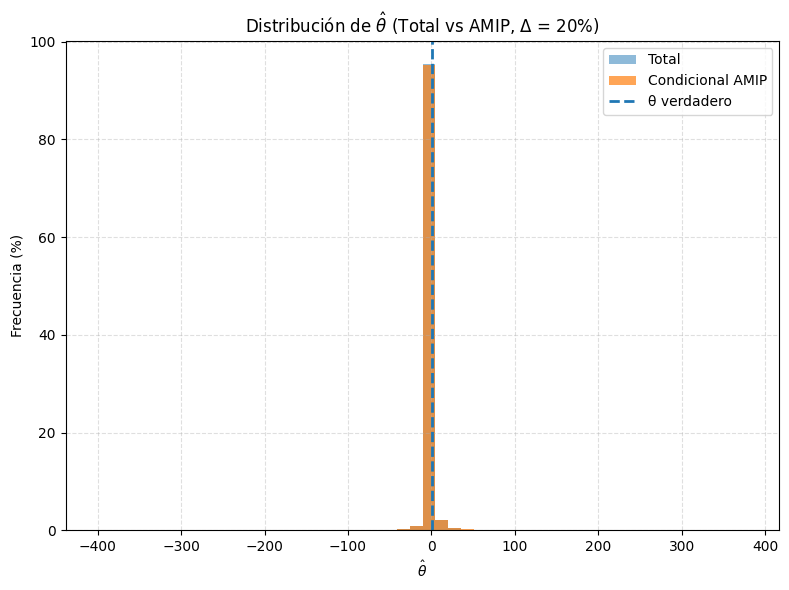

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN #OLS 20%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 0.2
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

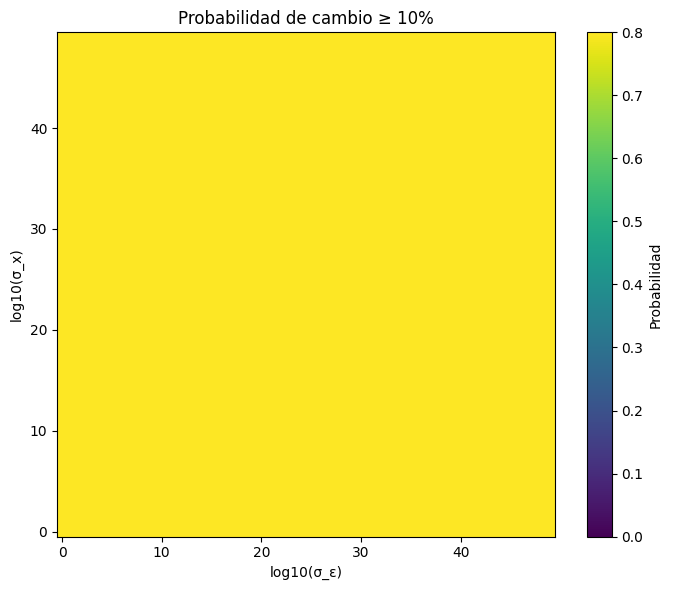

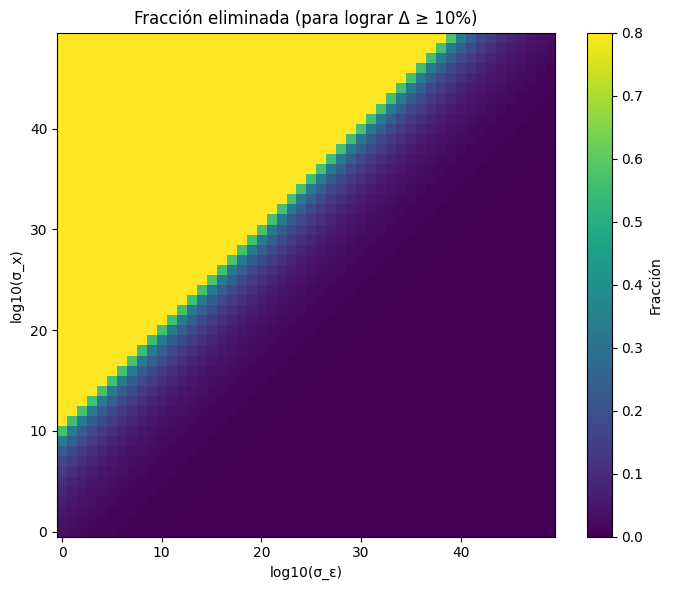


Estadísticas descriptivas de θ
Media: 0.9997
Mediana: 1.0000
Desv. estándar: 9.1278
Varianza: 83.3164
Mínimo: -406.5178
Máximo: 307.5953
P5: -0.6085
P25: 0.9923
P75: 1.0076
P95: 2.5252
Bias: -0.0003
Bias relativo (%): -0.03%

θ condicionado a éxito AMIP
Media: 0.9996
Mediana: 1.0000
Desv. estándar: 9.1679
Bias: -0.0004
Bias (%): -0.04%


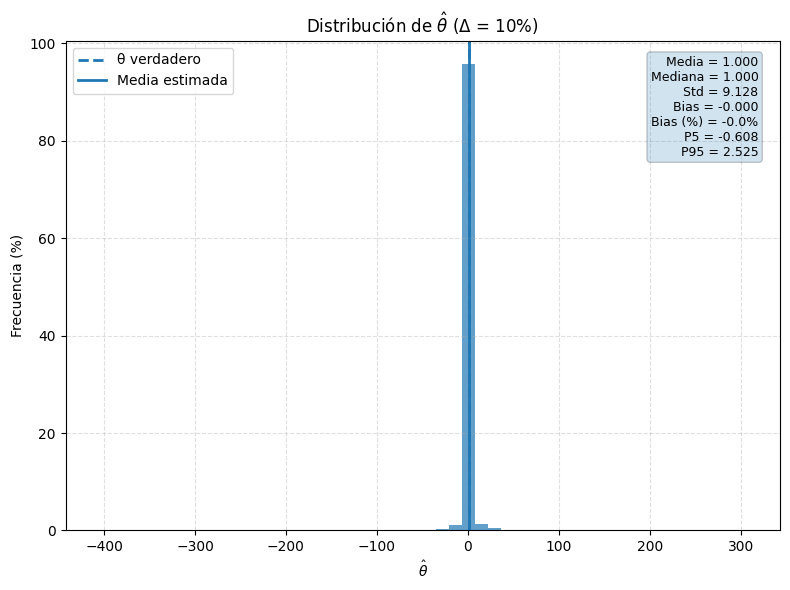

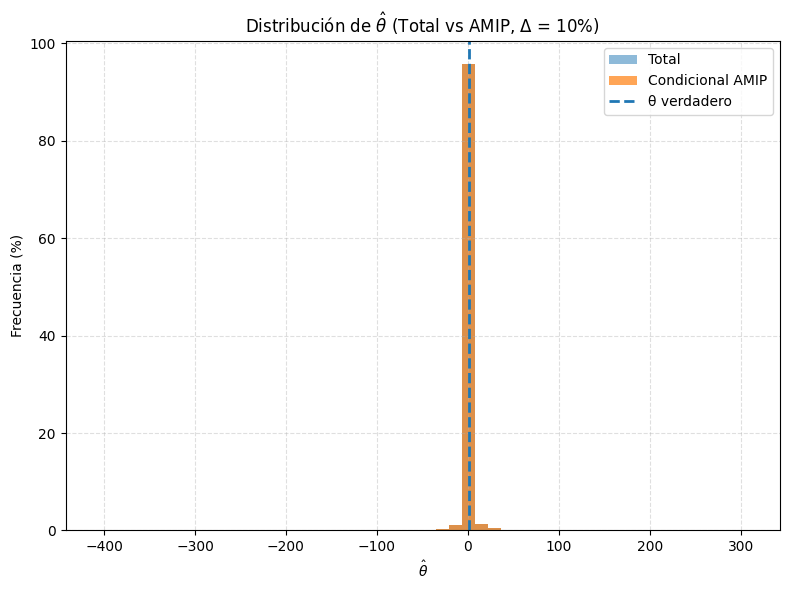

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 10%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 0.1
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

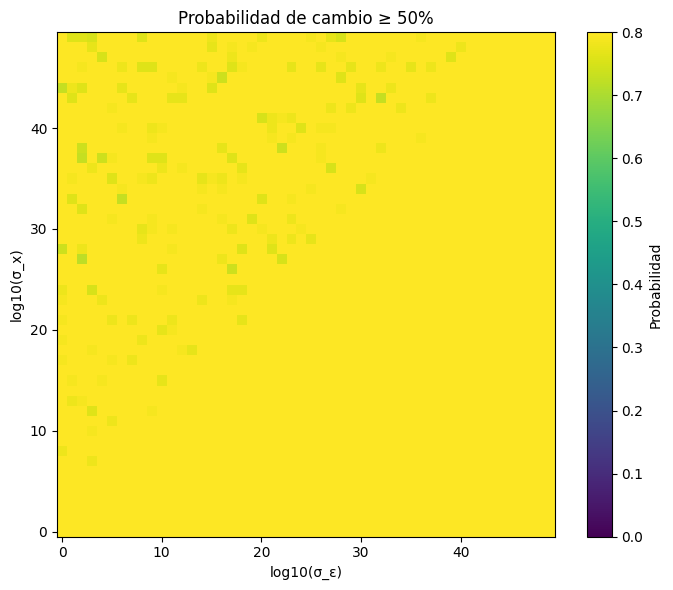

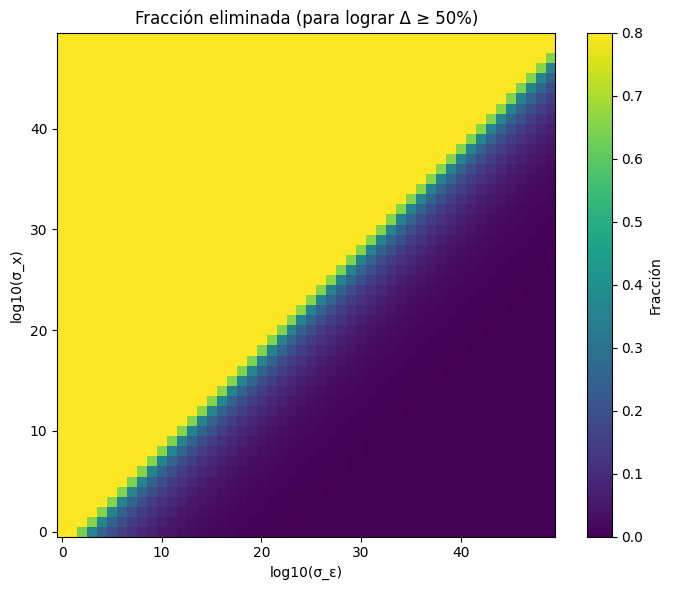


Estadísticas descriptivas de θ
Media: 2.0053
Mediana: 2.0000
Desv. estándar: 9.0905
Varianza: 82.6372
Mínimo: -337.2919
Máximo: 382.0317
P5: 0.4450
P25: 1.9923
P75: 2.0077
P95: 3.5787
Bias: 1.0053
Bias relativo (%): 100.53%

θ condicionado a éxito AMIP
Media: 2.0058
Mediana: 2.0000
Desv. estándar: 9.4763
Bias: 1.0058
Bias (%): 100.58%


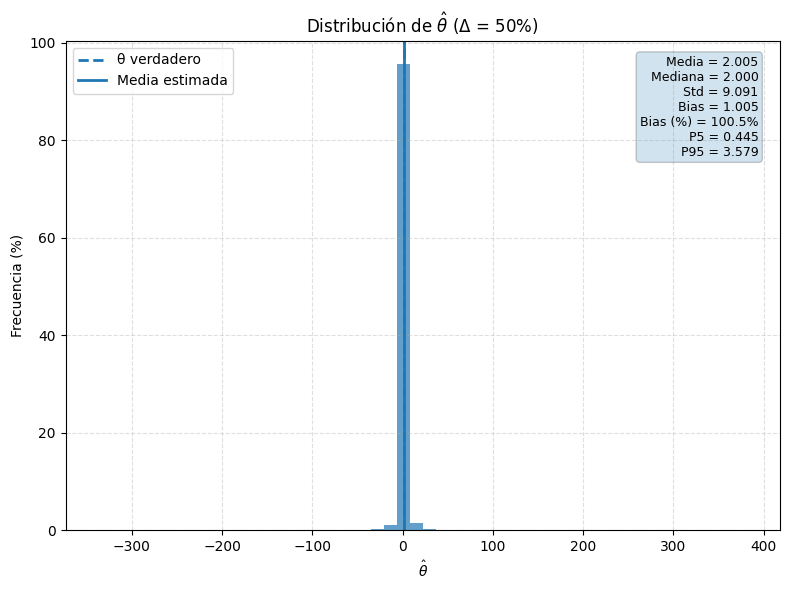

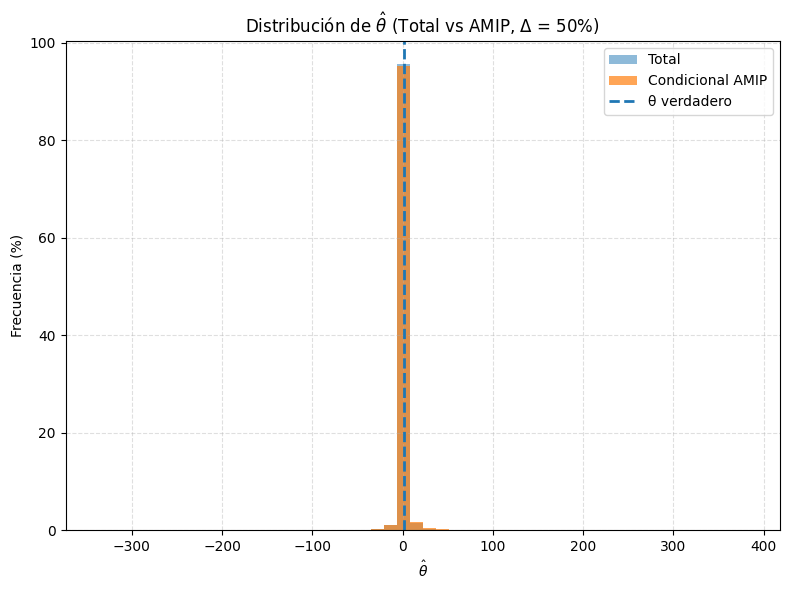

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 50% + ENDOGENEIDAD
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = True
USE_HETEROSKEDASTICITY = False

DELTA = 0.5
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

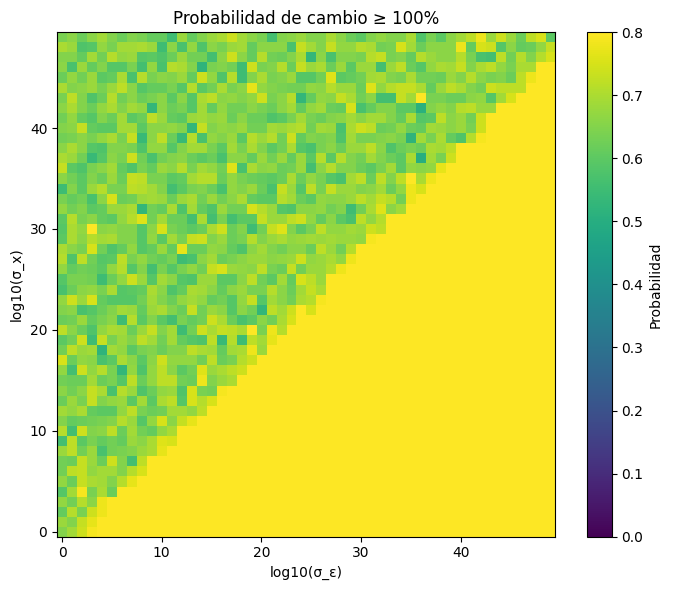

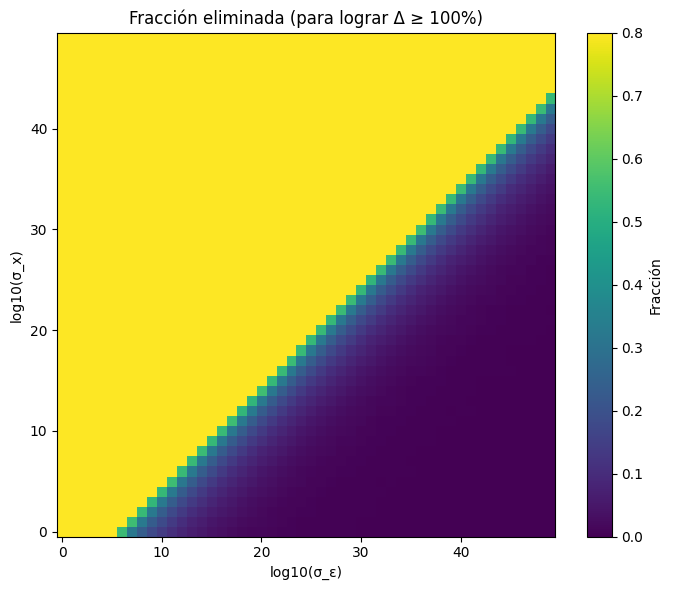


Estadísticas descriptivas de θ
Media: 2.0300
Mediana: 2.0000
Desv. estándar: 9.1326
Varianza: 83.4047
Mínimo: -321.0071
Máximo: 400.1544
P5: 0.4345
P25: 1.9923
P75: 2.0076
P95: 3.5489
Bias: 1.0300
Bias relativo (%): 103.00%

θ condicionado a éxito AMIP
Media: 2.0370
Mediana: 2.0000
Desv. estándar: 10.1500
Bias: 1.0370
Bias (%): 103.70%


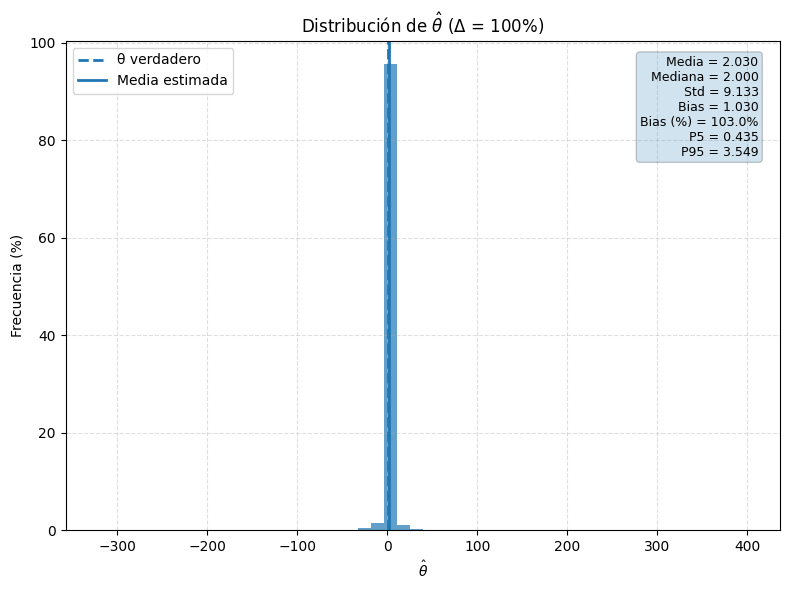

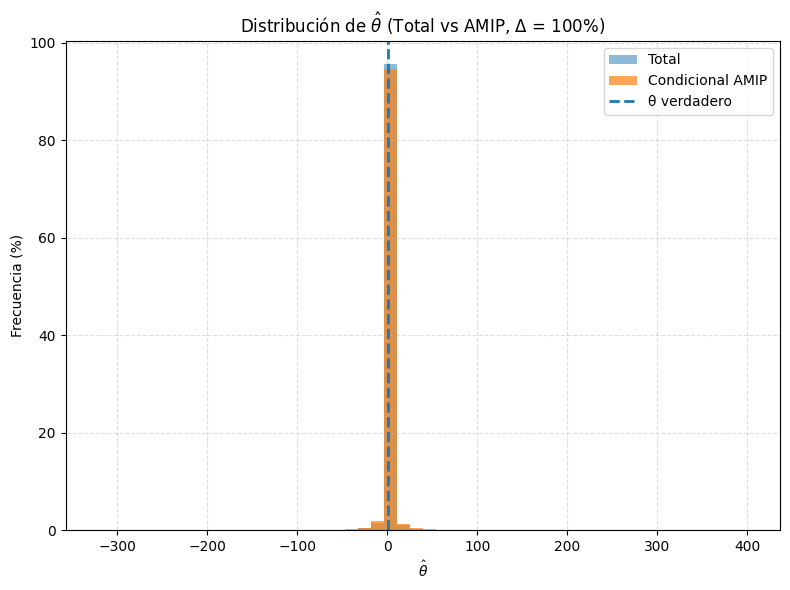

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + ENDOGENEIDAD
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = True
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

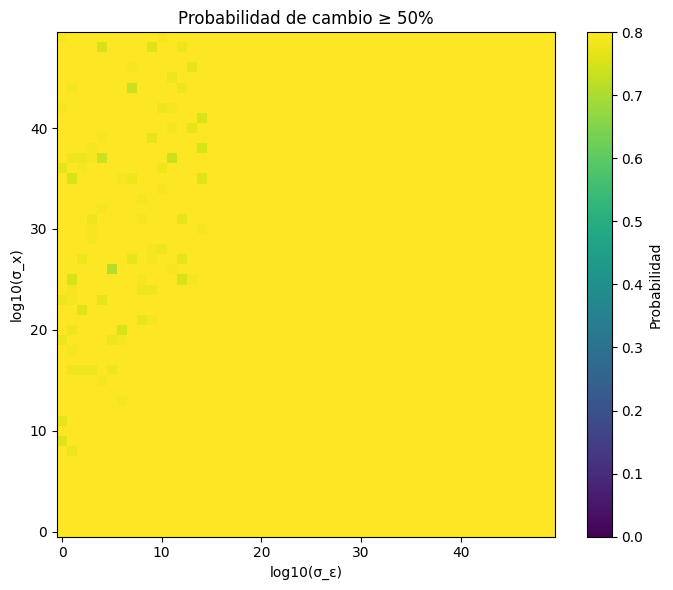

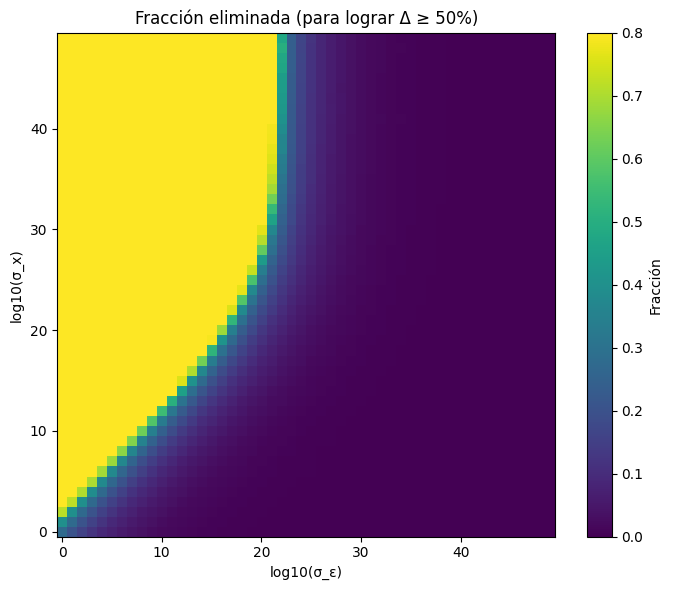


Estadísticas descriptivas de θ
Media: 1.0200
Mediana: 1.0000
Desv. estándar: 9.3043
Varianza: 86.5705
Mínimo: -329.2214
Máximo: 343.7714
P5: -1.4302
P25: 0.9619
P75: 1.0387
P95: 3.4574
Bias: 0.0200
Bias relativo (%): 2.00%

θ condicionado a éxito AMIP
Media: 1.0208
Mediana: 1.0000
Desv. estándar: 9.4890
Bias: 0.0208
Bias (%): 2.08%


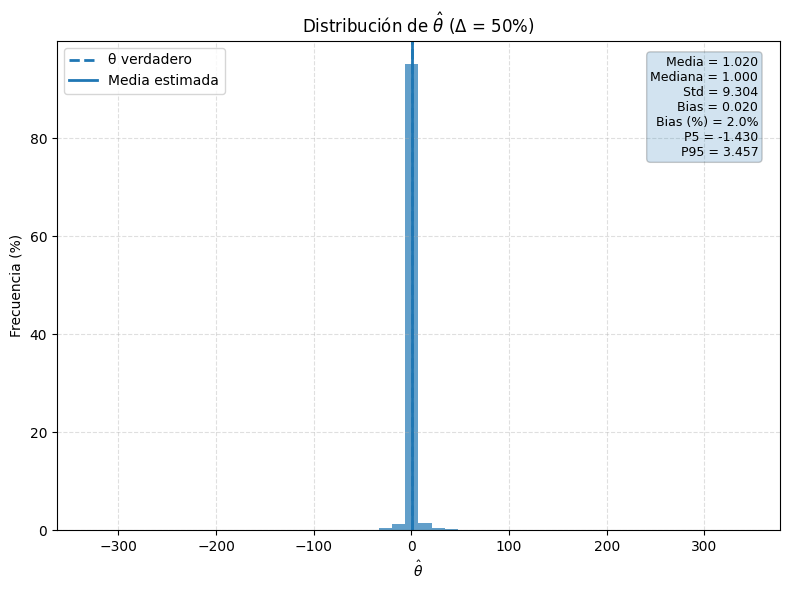

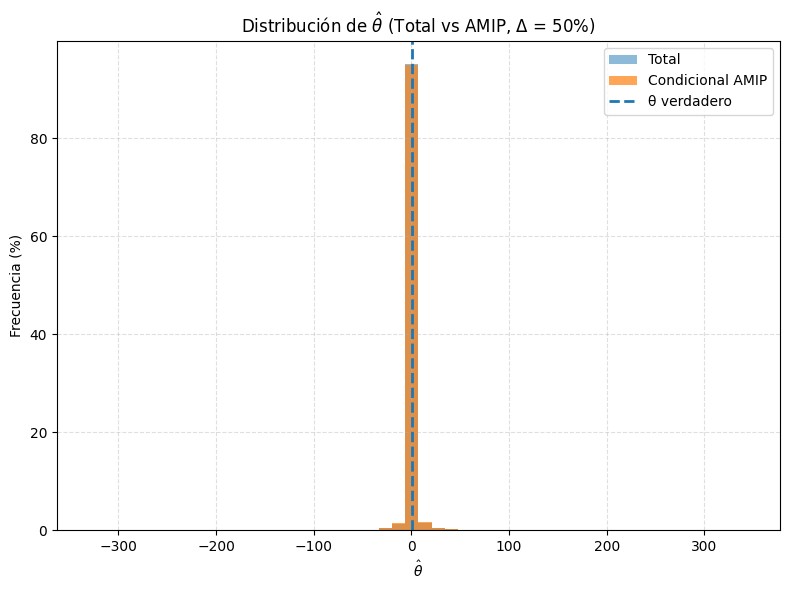

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 50% + HETEROCEDASTICIDAD
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = True

DELTA = 0.5
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

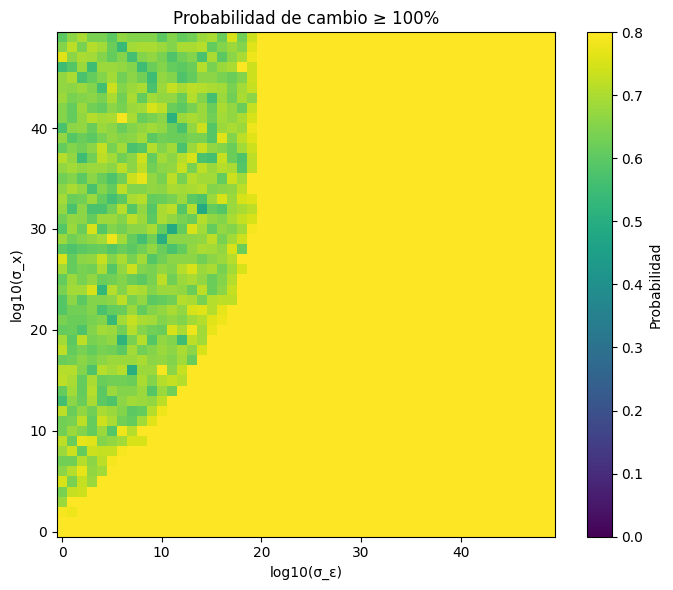

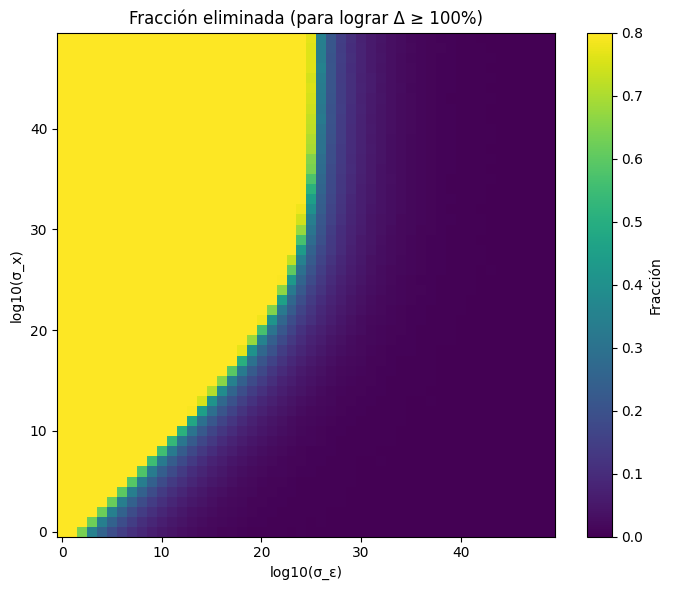


Estadísticas descriptivas de θ
Media: 0.9958
Mediana: 1.0000
Desv. estándar: 9.2011
Varianza: 84.6594
Mínimo: -384.6920
Máximo: 455.1335
P5: -1.4394
P25: 0.9615
P75: 1.0383
P95: 3.4273
Bias: -0.0042
Bias relativo (%): -0.42%

θ condicionado a éxito AMIP
Media: 0.9953
Mediana: 1.0000
Desv. estándar: 9.7161
Bias: -0.0047
Bias (%): -0.47%


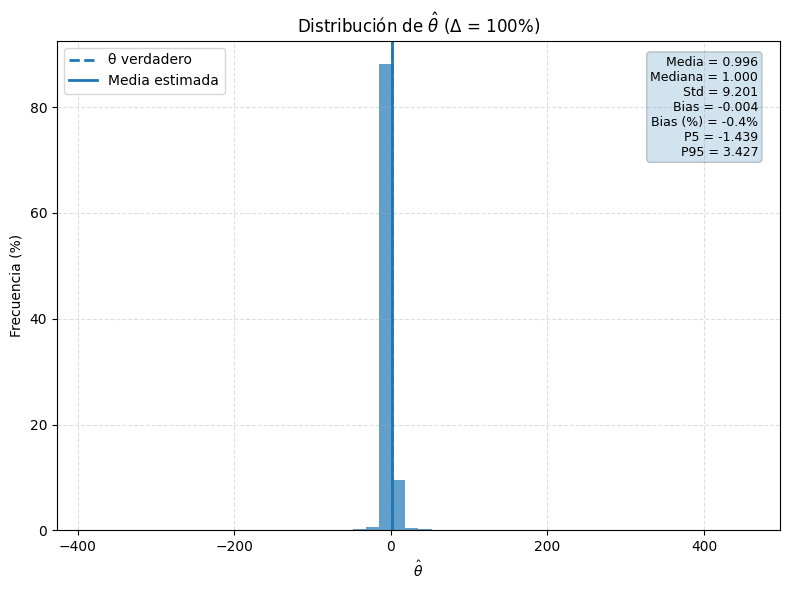

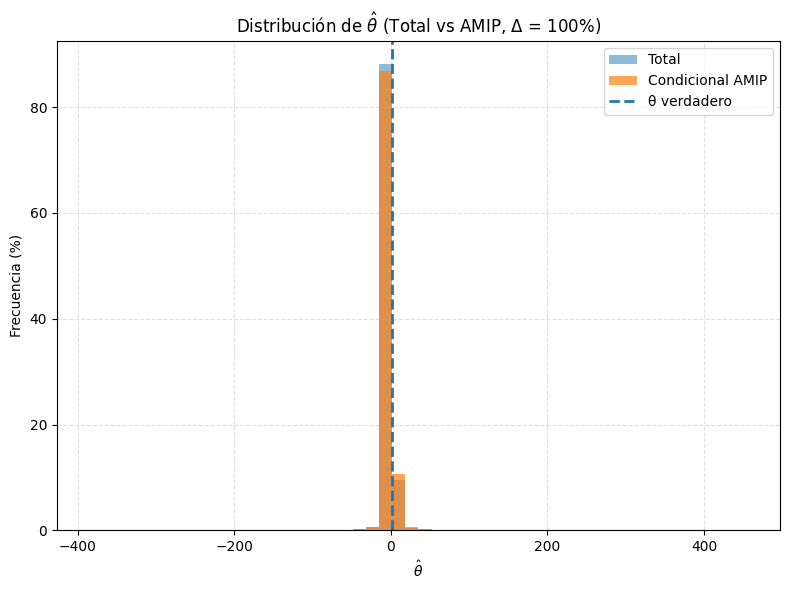

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN ols 100% + heterocedasticidad
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = True

DELTA = 1
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

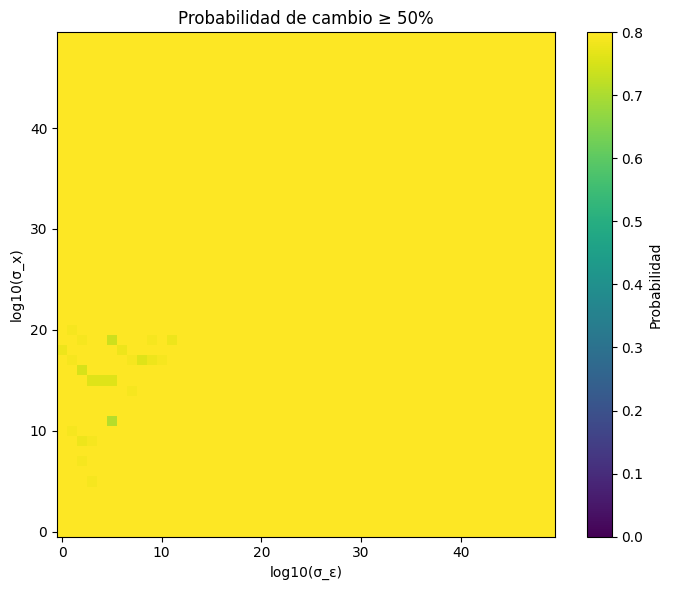

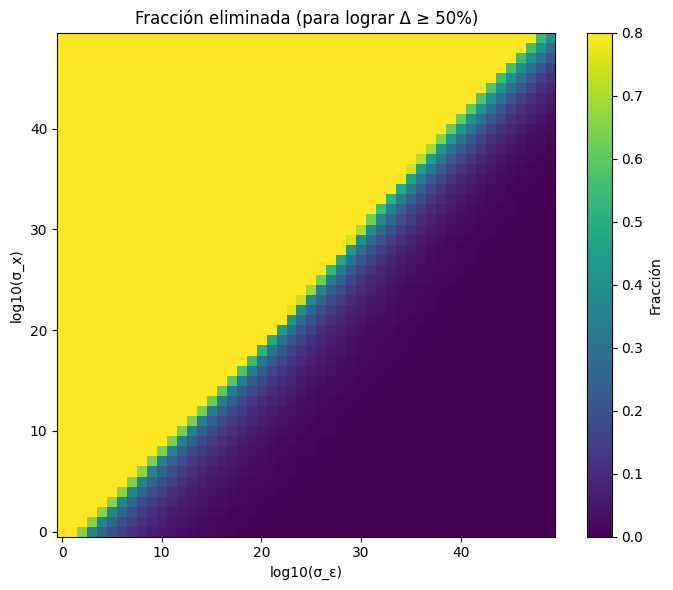


Estadísticas descriptivas de θ
Media: 20.6209
Mediana: 4.5316
Desv. estándar: 36.9421
Varianza: 1364.7169
Mínimo: -328.1996
Máximo: 382.8429
P5: 0.2692
P25: 2.2543
P75: 20.9409
P95: 111.6850
Bias: 19.6209
Bias relativo (%): 1962.09%

θ condicionado a éxito AMIP
Media: 20.8978
Mediana: 4.5843
Desv. estándar: 37.1526
Bias: 19.8978
Bias (%): 1989.78%


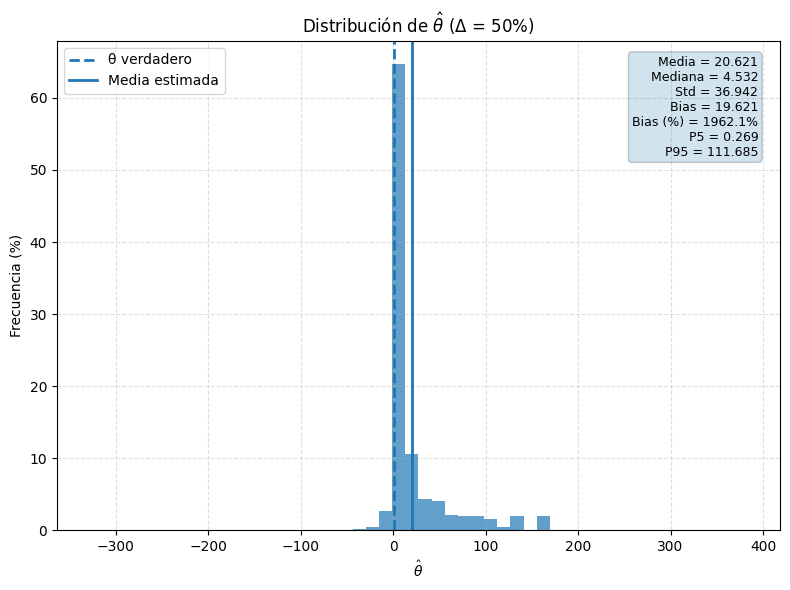

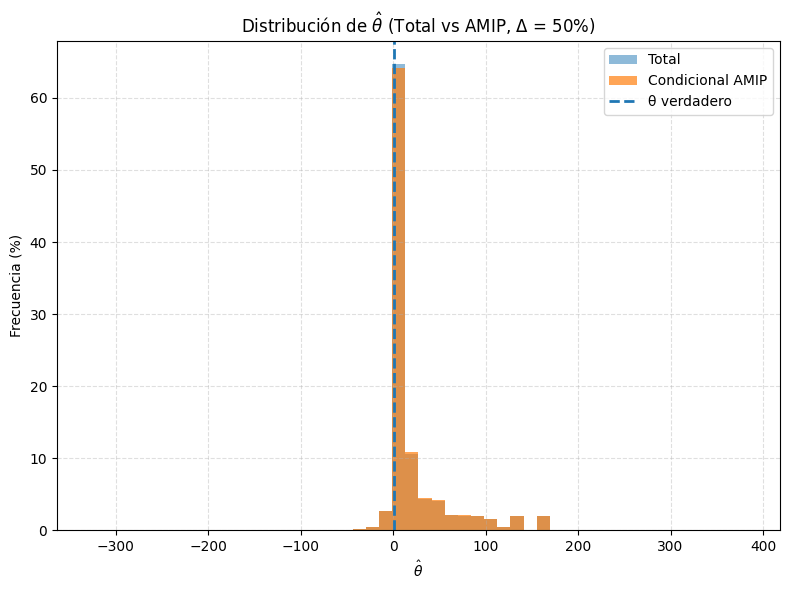

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 50% ENDOGENEIDAD + HETEROCEDASTICIDAD
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = True
USE_HETEROSKEDASTICITY = True

DELTA = 0.5
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

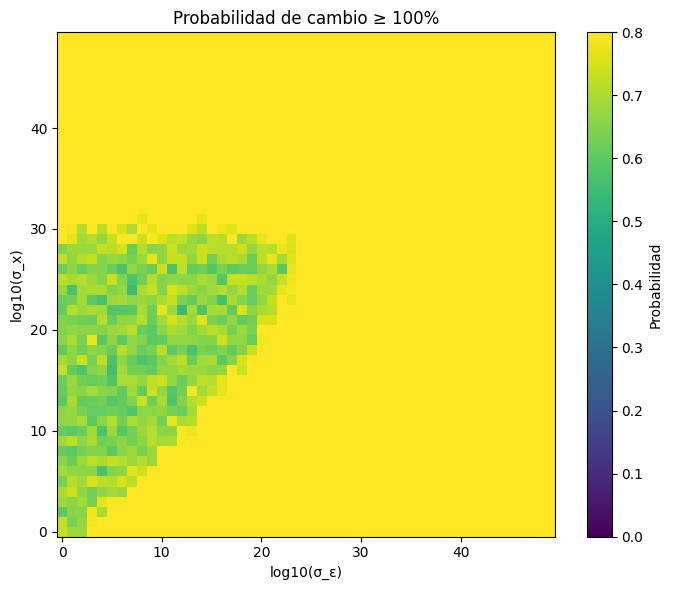

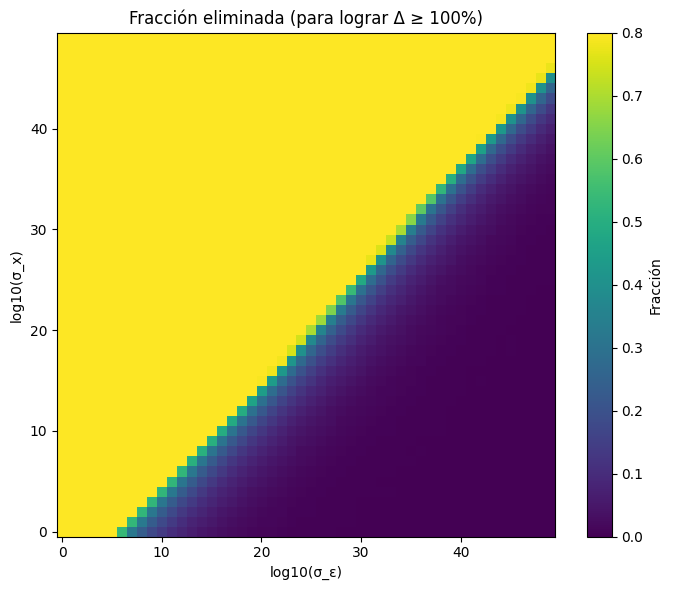


Estadísticas descriptivas de θ
Media: 20.6068
Mediana: 4.5355
Desv. estándar: 36.9799
Varianza: 1367.5111
Mínimo: -367.1369
Máximo: 418.3342
P5: 0.3285
P25: 2.2530
P75: 20.9762
P95: 111.6783
Bias: 19.6068
Bias relativo (%): 1960.68%

θ condicionado a éxito AMIP
Media: 21.9066
Mediana: 5.0633
Desv. estándar: 38.0384
Bias: 20.9066
Bias (%): 2090.66%


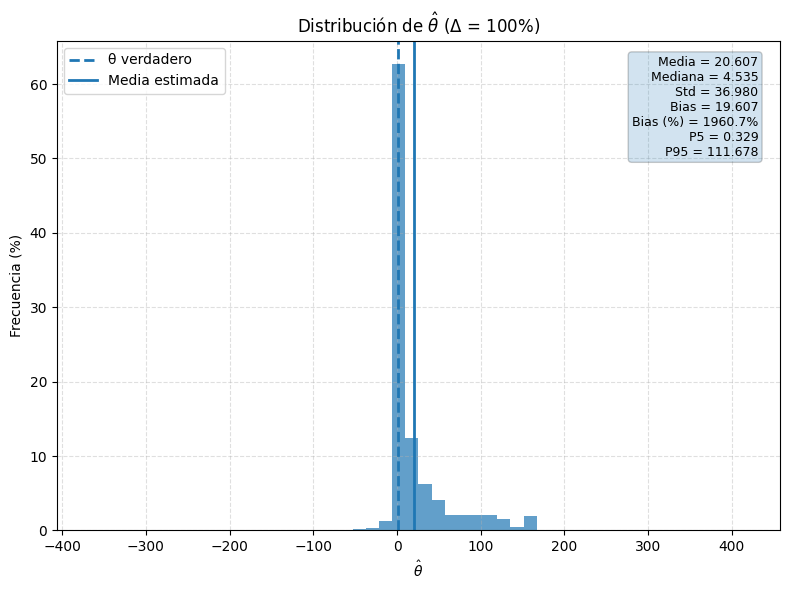

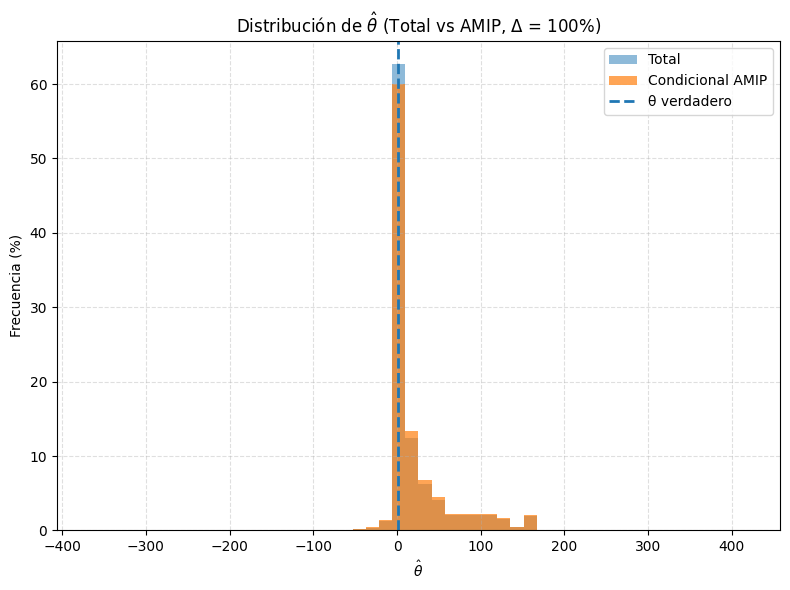

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLE 100% + HETEROCEDASTICIDAD Y ENDOGENEIDAD
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = True
USE_HETEROSKEDASTICITY = True

DELTA = 1
delta_label = f"{int(DELTA*100)}%"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous" #

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion" #proportion / rule
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    # =====================================================
    # 🔴 CASOS OLS / RCT / RDD / DiD / MLR (ya optimizados)
    # =====================================================
    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    # =====================================================
    # 🔴 IV OPTIMIZADO (NUEVO)
    # =====================================================
    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []
for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# HISTOGRAMA %
# =========================================================

# =========================================================
# 🔴 ESTADÍSTICAS DESCRIPTIVAS + HISTOGRAMA %
# =========================================================

theta_array = np.array(theta_samples)

# 🔴 Estadísticas
mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan
# =========================================================
# 🔴 PRINT (para tesis)
# =========================================================

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")
# =========================================================
# 🔴 ESTADÍSTICAS CONDICIONADAS (AMIP éxito)
# =========================================================

theta_success_array = np.array(theta_success)

if len(theta_success_array) > 0:

    mean_s = np.mean(theta_success_array)
    median_s = np.median(theta_success_array)
    std_s = np.std(theta_success_array)

    bias_s = mean_s - beta_main
    rel_bias_s = (bias_s / beta_main) * 100 if beta_main != 0 else np.nan

    print("\n============================")
    print("θ condicionado a éxito AMIP")
    print("============================")

    print(f"Media: {mean_s:.4f}")
    print(f"Mediana: {median_s:.4f}")
    print(f"Desv. estándar: {std_s:.4f}")
    print(f"Bias: {bias_s:.4f}")
    print(f"Bias (%): {rel_bias_s:.2f}%")

else:
    print("\nNo hubo casos exitosos AMIP.")


# =========================================================
# 🔴 HISTOGRAMA EN PORCENTAJE
# =========================================================

plt.figure(figsize=(8,6))

weights = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights, alpha=0.7)

# Líneas clave
plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")
plt.axvline(mean_theta, linestyle='solid', linewidth=2, label="Media estimada")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# =========================================================
# 🔴 CUADRO DE ESTADÍSTICAS EN EL GRÁFICO
# =========================================================

textstr = '\n'.join((
    f'Media = {mean_theta:.3f}',
    f'Mediana = {median_theta:.3f}',
    f'Std = {std_theta:.3f}',
    f'Bias = {bias:.3f}',
    f'Bias (%) = {rel_bias:.1f}%',
    f'P5 = {p5:.3f}',
    f'P95 = {p95:.3f}'
))

plt.text(
    0.97, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.2)
)

plt.tight_layout()
plt.show()
# =========================================================
# 🔴 HISTOGRAMA COMPARADO
# =========================================================

plt.figure(figsize=(8,6))

weights_all = np.ones_like(theta_array) / len(theta_array) * 100

plt.hist(theta_array, bins=50, weights=weights_all, alpha=0.5, label="Total")

if len(theta_success_array) > 0:
    weights_s = np.ones_like(theta_success_array) / len(theta_success_array) * 100

    plt.hist(
        theta_success_array,
        bins=50,
        weights=weights_s,
        alpha=0.7,
        label="Condicional AMIP"
    )

plt.axvline(beta_main, linestyle='dashed', linewidth=2, label="θ verdadero")

plt.xlabel(r"$\hat{\theta}$")
plt.ylabel("Frecuencia (%)")

plt.title(f"Distribución de $\\hat{{\\theta}}$ (Total vs AMIP, Δ = {delta_label})")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

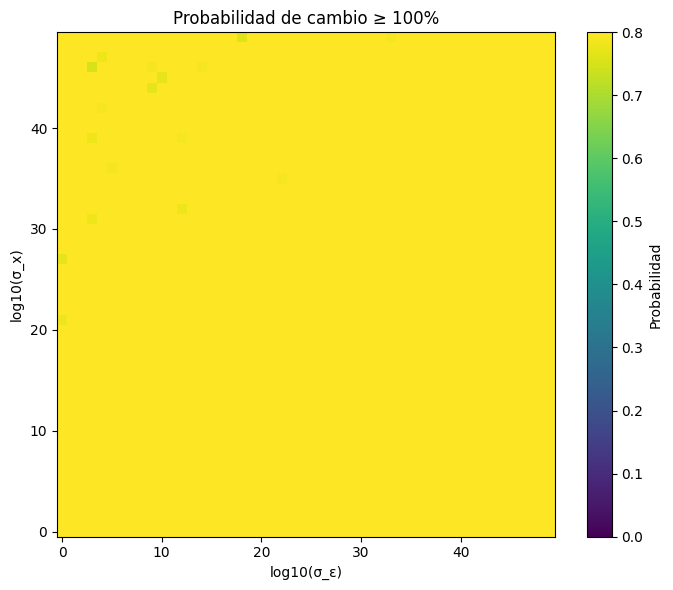

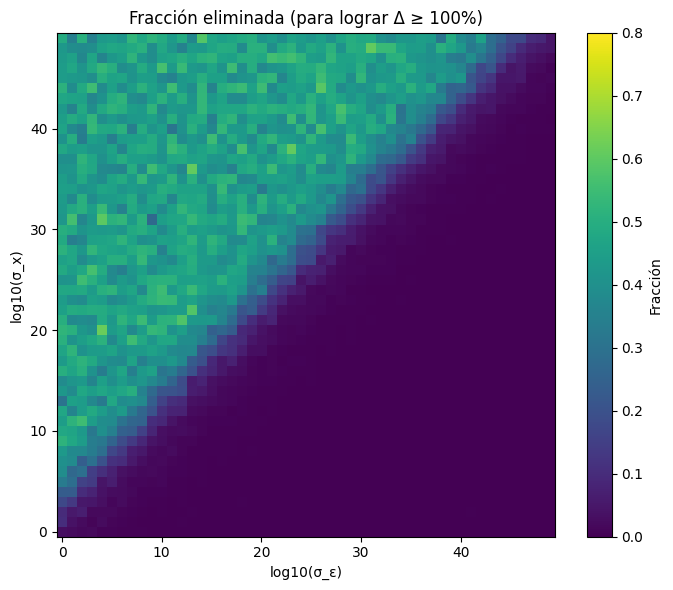


Estadísticas descriptivas de θ
Media: 0.4764
Mediana: 0.5034
Desv. estándar: 45.4176
Varianza: 2062.7598
Mínimo: -1688.7943
Máximo: 1866.3453
P5: -7.4560
P25: 0.4270
P75: 0.5846
P95: 8.3877
Bias: -0.5236
Bias relativo (%): -52.36%


In [11]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + ousiders escala *10 y 1% de outsiders
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = True 
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 10

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous"

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

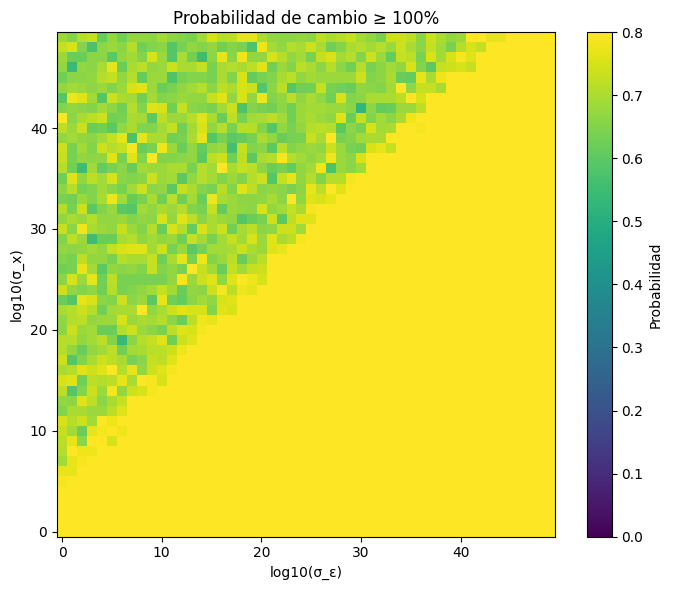

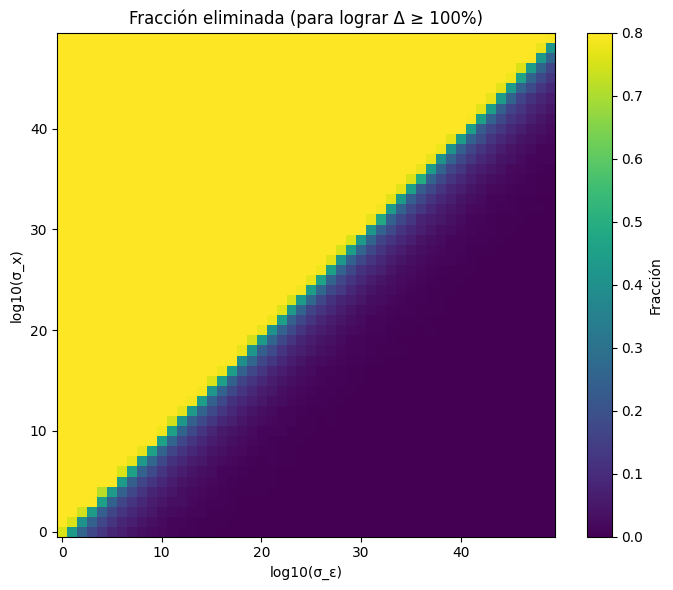


Estadísticas descriptivas de θ
Media: 0.7690
Mediana: 0.8021
Desv. estándar: 20.0777
Varianza: 403.1145
Mínimo: -729.3182
Máximo: 791.4272
P5: -2.6971
P25: 0.7556
P75: 0.8463
P95: 4.1954
Bias: -0.2310
Bias relativo (%): -23.10%


In [12]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + outsiders efecto *5 y 1% de estos
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = True
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 5

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous"

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

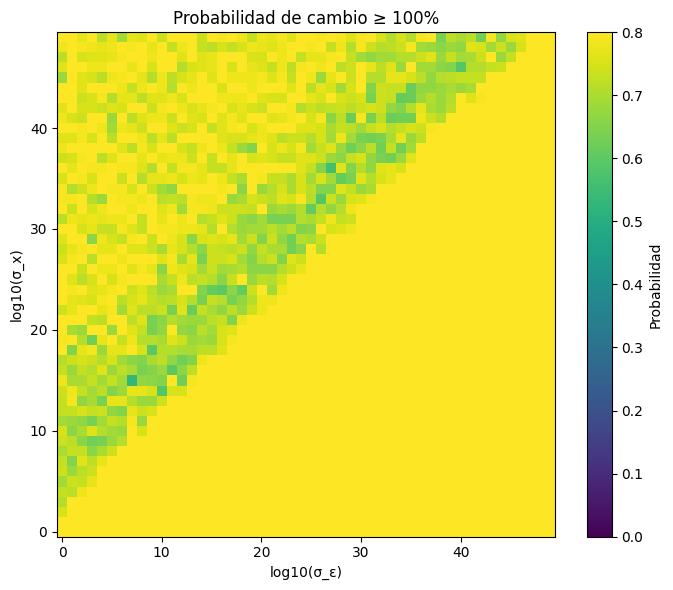

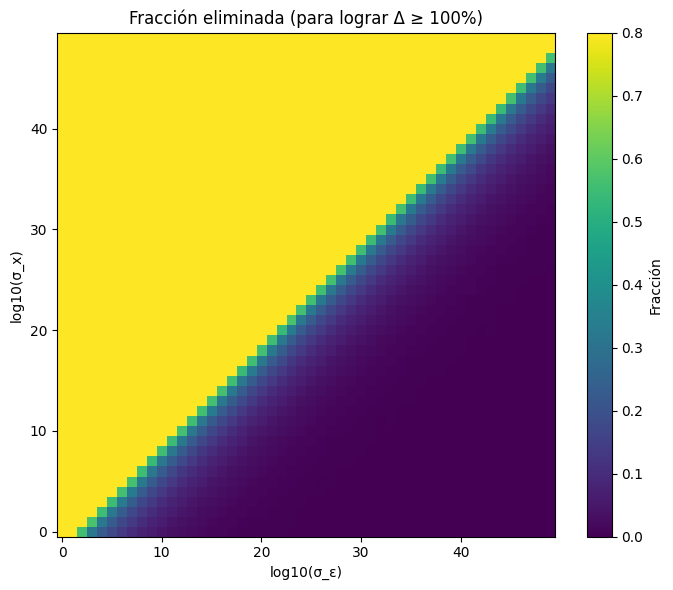


Estadísticas descriptivas de θ
Media: 0.9788
Mediana: 0.9620
Desv. estándar: 9.5922
Varianza: 92.0099
Mínimo: -420.5229
Máximo: 415.6138
P5: -0.6978
P25: 0.9476
P75: 0.9748
P95: 2.6375
Bias: -0.0212
Bias relativo (%): -2.12%


In [13]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + outsiders efecto *2 y 1% de estos
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = True
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous"

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

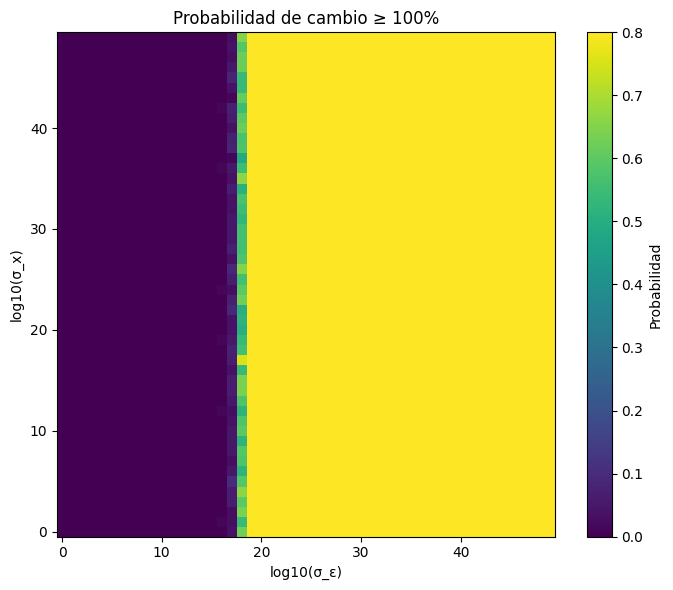

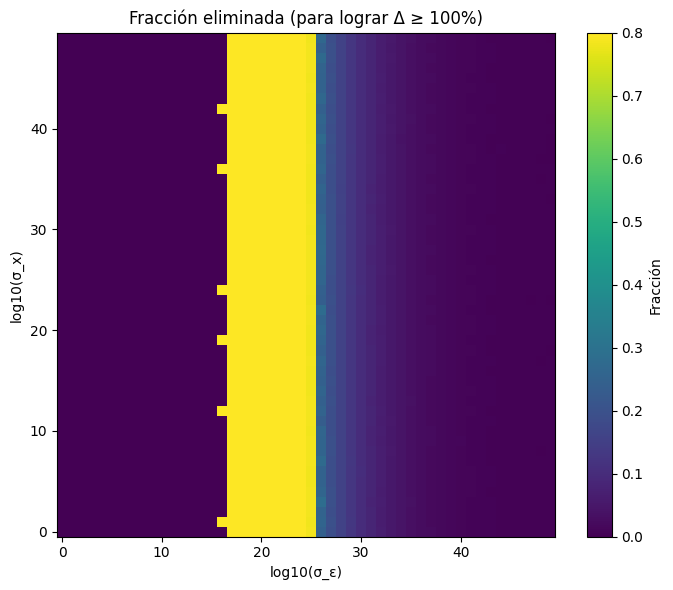


Estadísticas descriptivas de θ
Media: 1.0015
Mediana: 1.0000
Desv. estándar: 0.5051
Varianza: 0.2551
Mínimo: -6.0666
Máximo: 9.3357
P5: 0.4514
P25: 0.9894
P75: 1.0106
P95: 1.5593
Bias: 0.0015
Bias relativo (%): 0.15%


In [16]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN rct 100%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "RCT"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous"

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

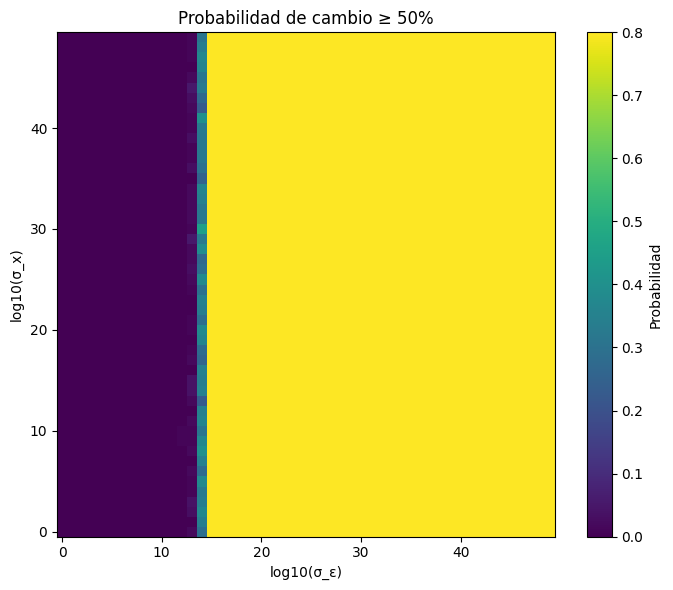

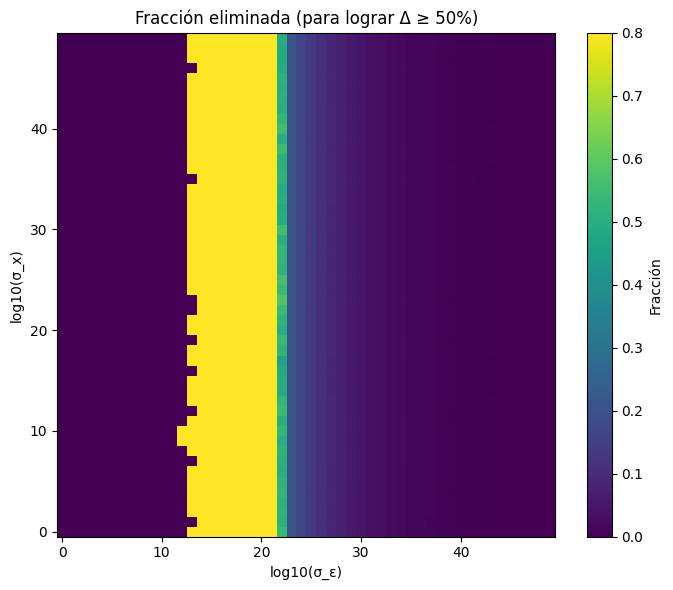


Estadísticas descriptivas de θ
Media: 1.0008
Mediana: 1.0000
Desv. estándar: 0.5068
Varianza: 0.2569
Mínimo: -5.9802
Máximo: 8.0562
P5: 0.4471
P25: 0.9894
P75: 1.0109
P95: 1.5595
Bias: 0.0008
Bias relativo (%): 0.08%


In [14]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN RCT 50%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "RCT"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 0.5
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "homogeneous"

beta_main = 1
beta_sub = 0

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.001

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

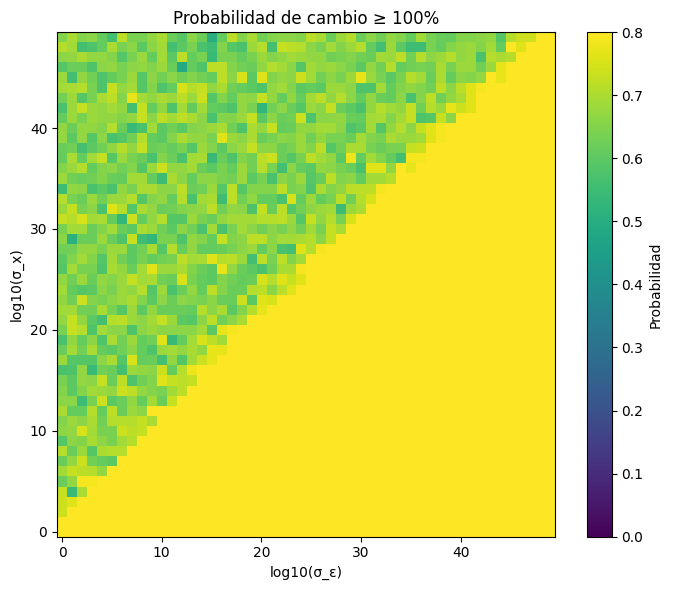

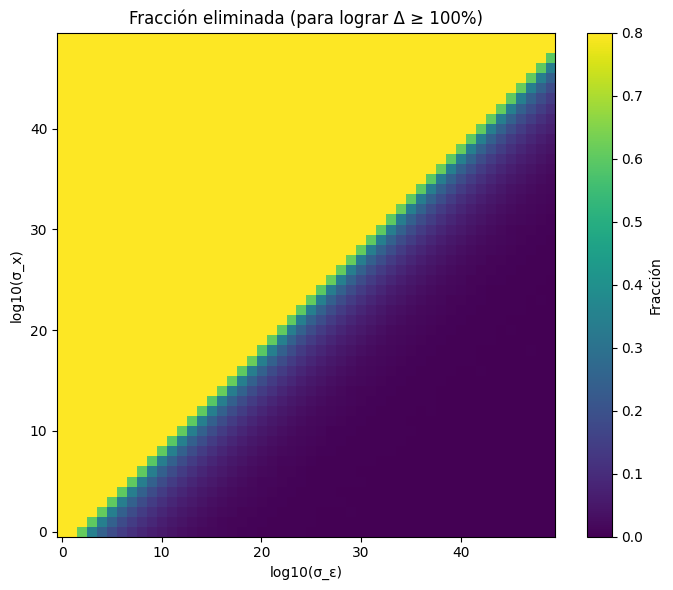


Estadísticas descriptivas de θ
Media: 0.9789
Mediana: 0.9802
Desv. estándar: 9.1030
Varianza: 82.8649
Mínimo: -430.0828
Máximo: 427.8789
P5: -0.6045
P25: 0.9706
P75: 0.9890
P95: 2.5612
Bias: -0.0211
Bias relativo (%): -2.11%


In [15]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 1 y subpoblacion de -1 del 1%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 1
beta_sub = -1

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.01

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

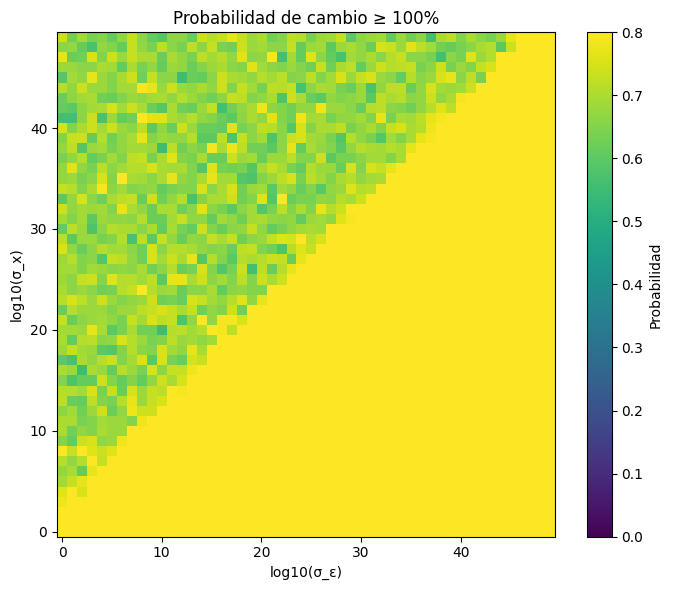

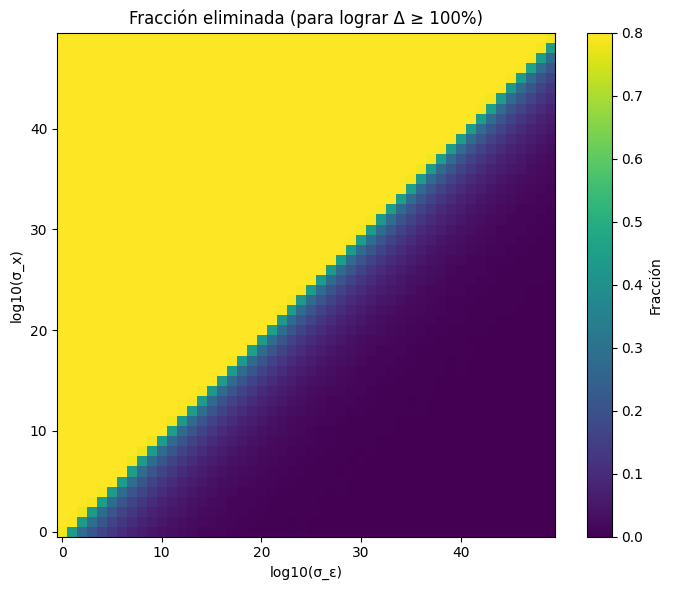


Estadísticas descriptivas de θ
Media: 0.7998
Mediana: 0.8001
Desv. estándar: 9.2046
Varianza: 84.7238
Mínimo: -360.6028
Máximo: 355.2000
P5: -0.7775
P25: 0.7819
P75: 0.8175
P95: 2.3526
Bias: -0.2002
Bias relativo (%): -20.02%


In [17]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 1 y subpoblacion de -1 del 10%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 1
beta_sub = -1

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.1

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

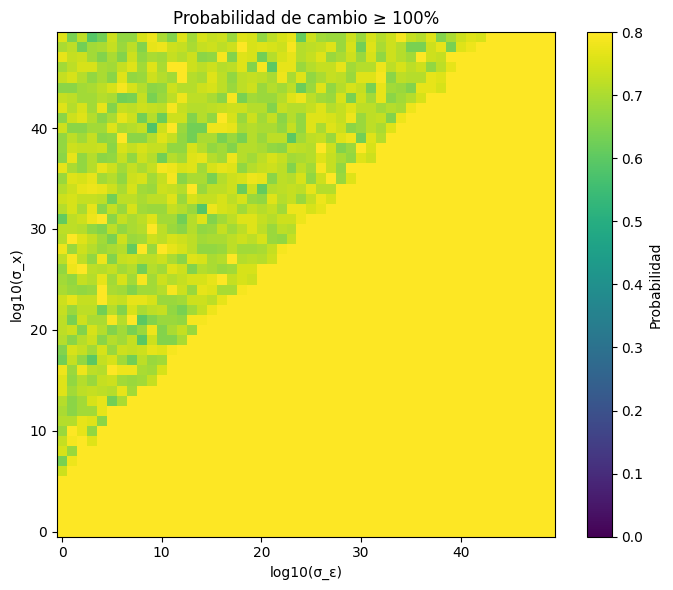

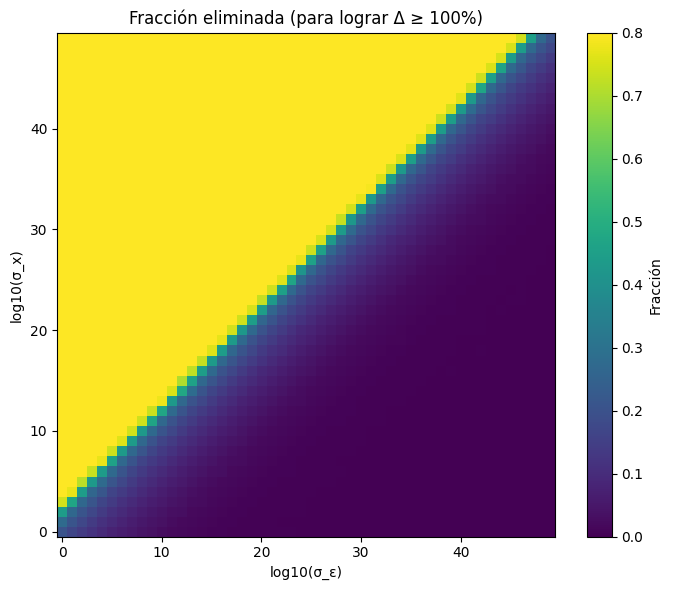


Estadísticas descriptivas de θ
Media: 0.5858
Mediana: 0.6001
Desv. estándar: 8.9085
Varianza: 79.3621
Mínimo: -301.3815
Máximo: 311.4721
P5: -0.9579
P25: 0.5779
P75: 0.6218
P95: 2.1582
Bias: -0.4142
Bias relativo (%): -41.42%


In [18]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 1 y subpoblacion de -1 del 20%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 1
beta_sub = -1

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.2

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

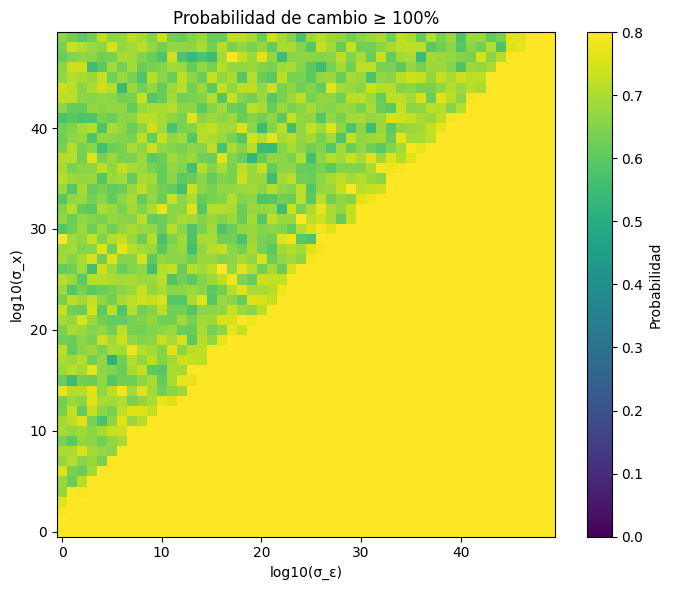

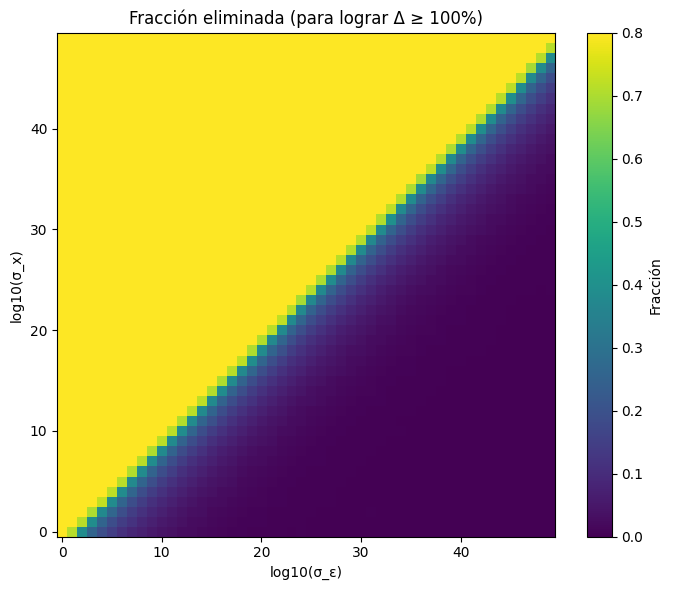


Estadísticas descriptivas de θ
Media: 0.9200
Mediana: 0.8911
Desv. estándar: 8.9383
Varianza: 79.8932
Mínimo: -329.9052
Máximo: 373.1528
P5: -0.6681
P25: 0.8615
P75: 0.9170
P95: 2.4727
Bias: -0.0800
Bias relativo (%): -8.00%


In [19]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 1 y subpoblacion de -10 del 1%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 1
beta_sub = -10

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.01

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

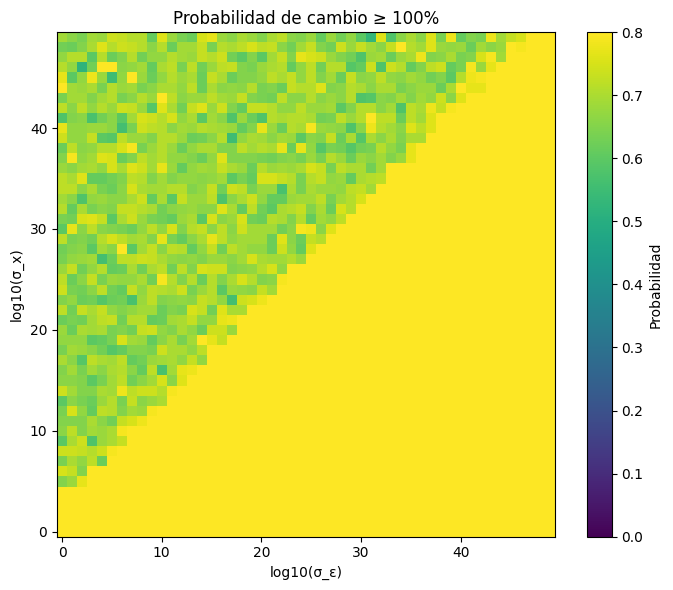

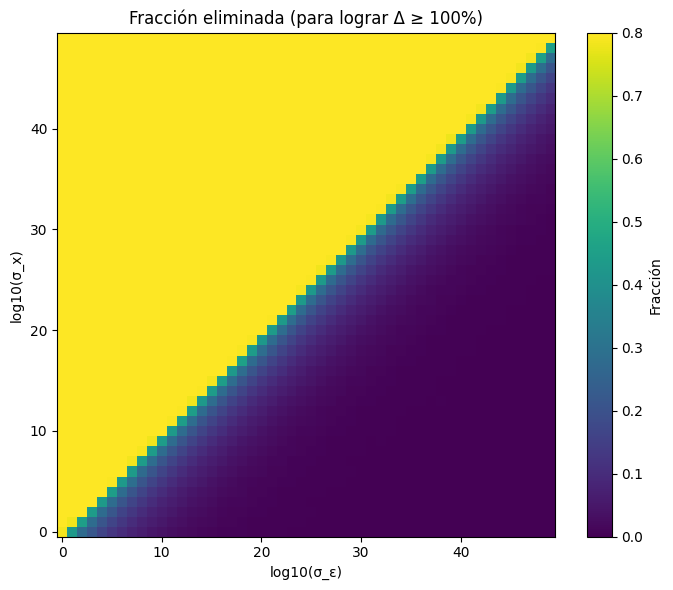


Estadísticas descriptivas de θ
Media: 0.7807
Mediana: 0.8002
Desv. estándar: 9.3093
Varianza: 86.6623
Mínimo: -577.2523
Máximo: 341.0126
P5: -0.7713
P25: 0.7820
P75: 0.8177
P95: 2.3883
Bias: -0.2193
Bias relativo (%): -21.93%


In [20]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 1 y subpoblacion de -10 del 10%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 1
beta_sub = -1

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.1

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

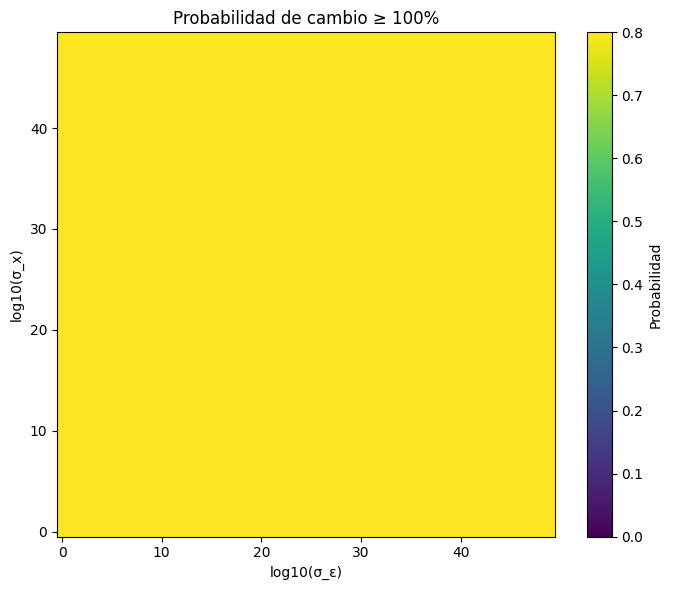

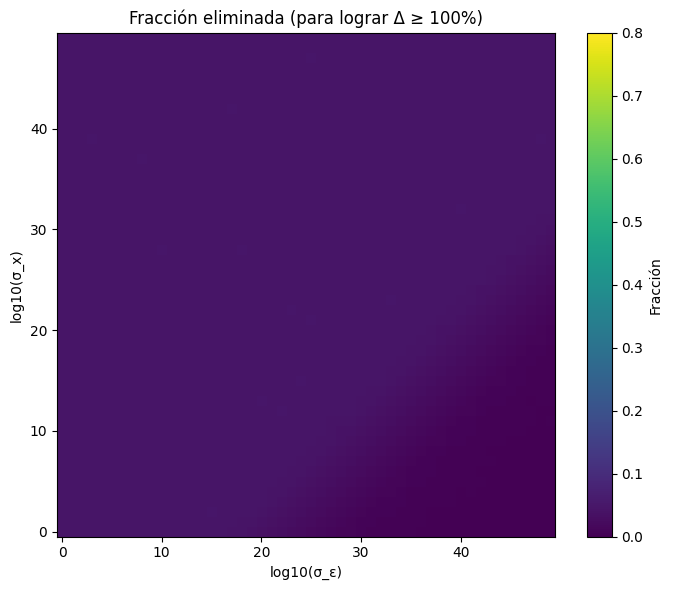


Estadísticas descriptivas de θ
Media: -9.1043
Mediana: -9.0911
Desv. estándar: 8.9309
Varianza: 79.7602
Mínimo: -390.6396
Máximo: 334.5628
P5: -10.9605
P25: -9.5882
P75: -8.6039
P95: -7.3204
Bias: -10.1043
Bias relativo (%): -1010.43%


In [21]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 1 y subpoblacion de -100 del 10%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 1
beta_sub = -100

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.1

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

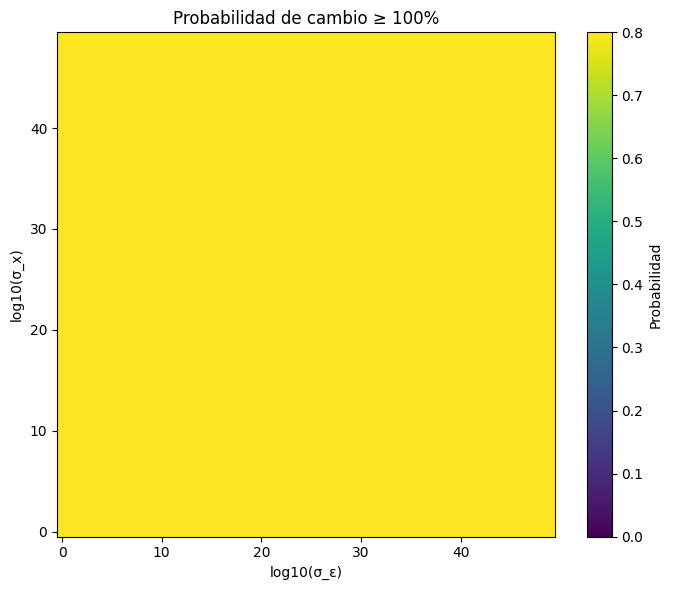

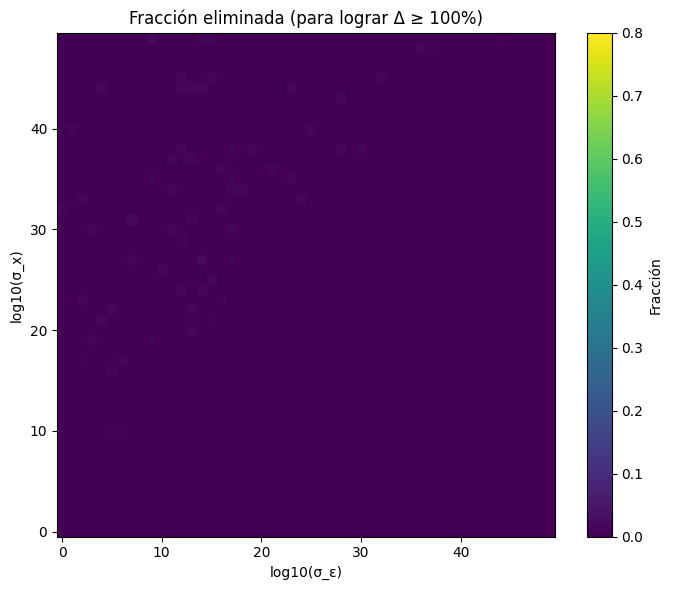


Estadísticas descriptivas de θ
Media: -0.0224
Mediana: 0.0023
Desv. estándar: 9.0742
Varianza: 82.3417
Mínimo: -376.6037
Máximo: 332.7137
P5: -1.6439
P25: -0.1876
P75: 0.1711
P95: 1.5270
Bias: -1.0224
Bias relativo (%): -102.24%


In [22]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 1 y subpoblacion de -100 del 1%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.01
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 1
beta_sub = -100

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.01

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

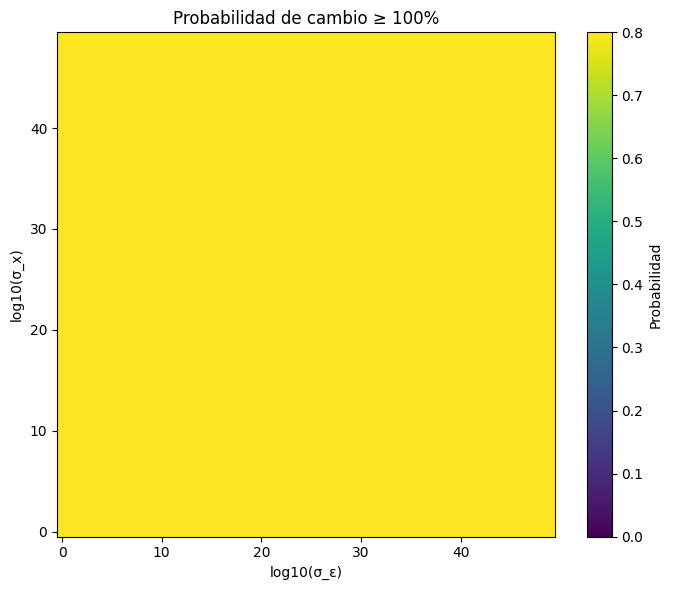

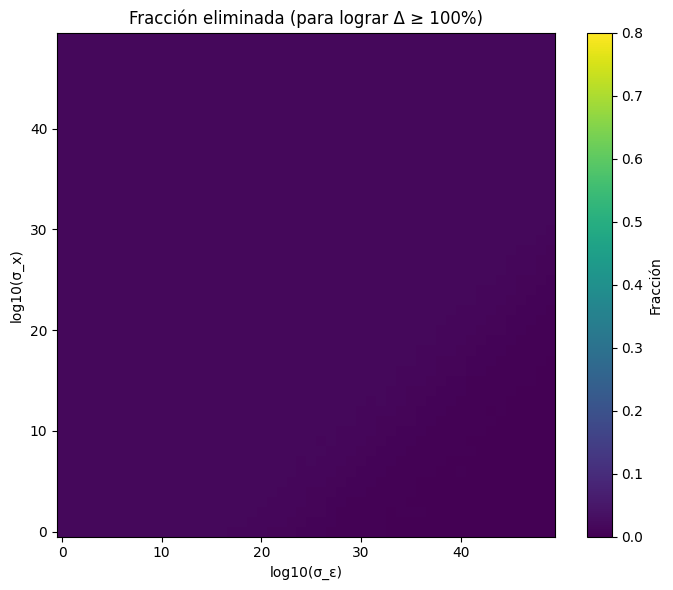


Estadísticas descriptivas de θ
Media: -4.0625
Mediana: -4.0392
Desv. estándar: 9.0840
Varianza: 82.5189
Mínimo: -363.7340
Máximo: 380.8073
P5: -5.7525
P25: -4.4134
P75: -3.6805
P95: -2.4484
Bias: -5.0625
Bias relativo (%): -506.25%


In [24]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 1 y subpoblacion de -100 del 5%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.05
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 1
beta_sub = -100

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.05

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

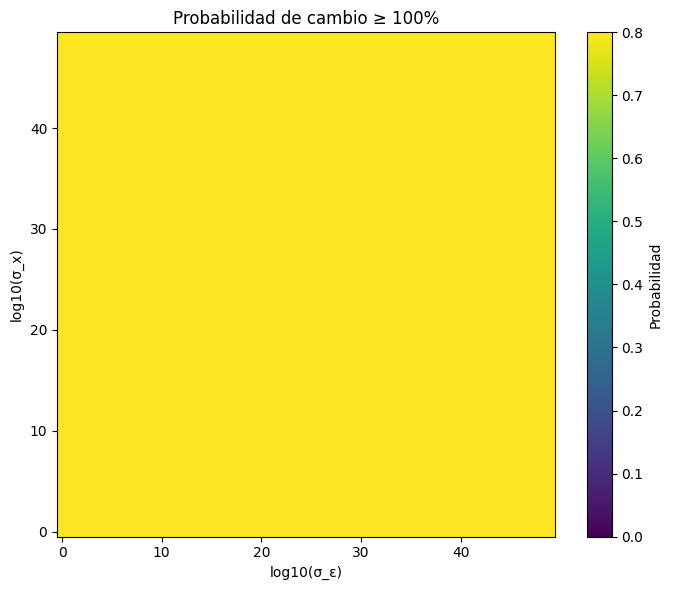

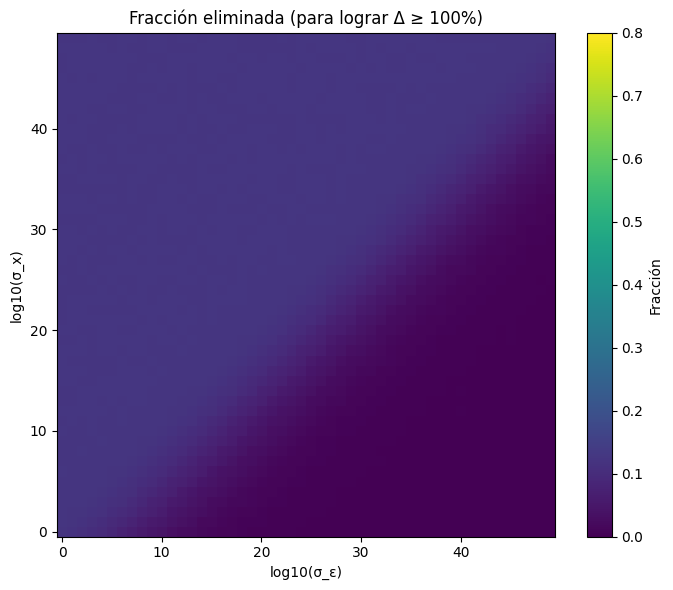


Estadísticas descriptivas de θ
Media: 1.0094
Mediana: 0.9879
Desv. estándar: 8.8857
Varianza: 78.9560
Mínimo: -445.6210
Máximo: 312.7525
P5: -0.5444
P25: 0.8191
P75: 1.1757
P95: 2.6110
Bias: 1.0094
Bias relativo (%): nan%


In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 0 y subpoblacion de 100 del 1%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.05
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 0
beta_sub = 100

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.01

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

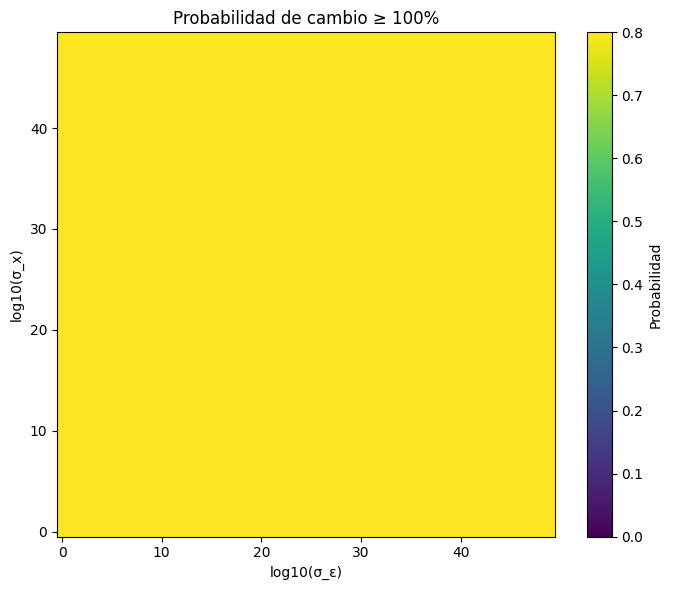

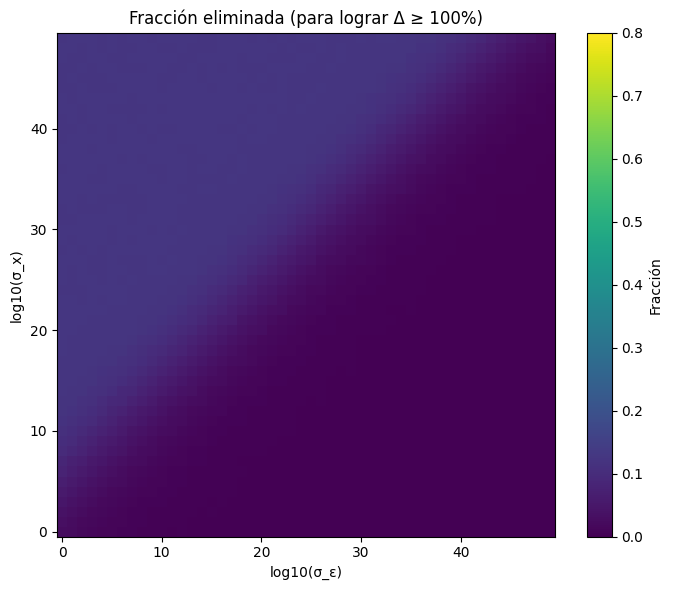


Estadísticas descriptivas de θ
Media: 0.0865
Mediana: 0.0988
Desv. estándar: 9.0095
Varianza: 81.1712
Mínimo: -456.1561
Máximo: 317.5598
P5: -1.4968
P25: 0.0747
P75: 0.1262
P95: 1.6447
Bias: 0.0865
Bias relativo (%): nan%


In [26]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 0 y subpoblacion de 10 del 1%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 1
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.05
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 0
beta_sub = 10

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.01

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

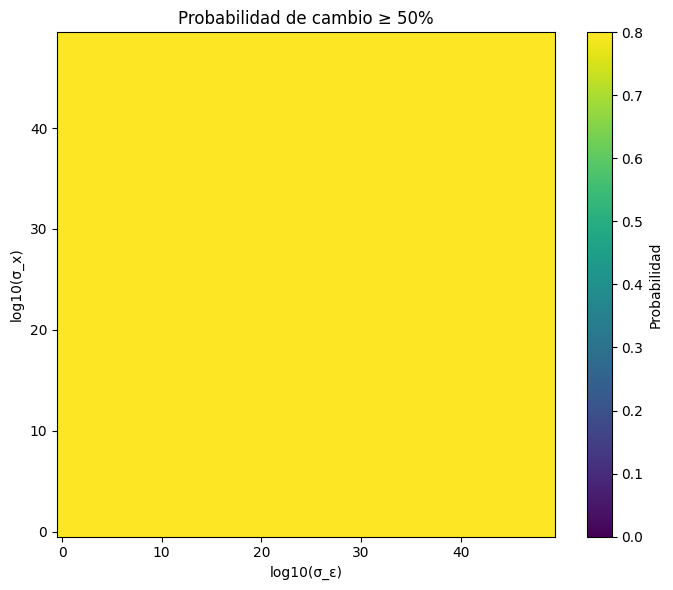

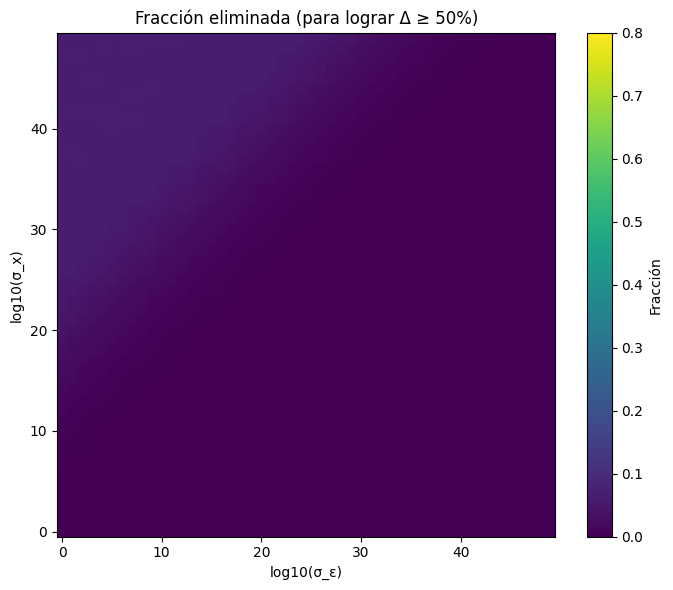


Estadísticas descriptivas de θ
Media: 0.0197
Mediana: 0.0099
Desv. estándar: 9.0001
Varianza: 81.0009
Mínimo: -319.0679
Máximo: 508.9940
P5: -1.5213
P25: 0.0021
P75: 0.0181
P95: 1.5752
Bias: 0.0197
Bias relativo (%): nan%


In [28]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 0 y subpoblacion de 1 del 1%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD", "MLR"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 0.5
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.05
OUTLIER_SCALE = 2

# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 0
beta_sub = 1

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.01

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN OLS 100% + efecto original 0 y subpoblacion de 1 del 1%
# =========================================================

N = 5000
TRIALS = 100

GRID_SIZE_X = 50
GRID_SIZE_E = 50

LOG_MIN_X = -2
LOG_MAX_X = 2
LOG_MIN_E = -2
LOG_MAX_E = 2

METHOD = "OLS"  # "OLS", "RCT", "RDD", "IV", "DiD"

USE_ENDOGENEITY = False
USE_HETEROSKEDASTICITY = False

DELTA = 0.5
delta_label = f"{int(DELTA*100)}%"

# =========================================================
# OUTLIERS (NUEVO)
# =========================================================

USE_OUTLIERS = False
OUTLIER_PROPORTION = 0.05
OUTLIER_SCALE = 2
# =========================================================
# RDD LOCAL (NUEVO)
# =========================================================

RDD_BANDWIDTH = 1.0

RDD_KERNEL = "triangular"  # "uniform", "triangular", "epanechnikov"
# =========================================================
# EFECTOS
# =========================================================

EFFECT_TYPE = "heterogeneous"

beta_main = 0
beta_sub = 1

# =========================================================
# SUBPOBLACIÓN
# =========================================================

SUBPOP_MODE = "proportion"
SUBPOP_PROPORTION = 0.01

def get_subpopulation_mask(x):
    if SUBPOP_MODE == "rule":
        return x > 0
    else:
        N = len(x)
        k = int(N * SUBPOP_PROPORTION)
        mask = np.zeros(N, dtype=bool)
        idx = np.random.choice(N, k, replace=False)
        mask[idx] = True
        return mask

# =========================================================
# PARÁMETROS MÉTODOS
# =========================================================

p_treat = 0.5
RDD_CUTOFF = 0.0

# =========================================================
# GRILLAS
# =========================================================

log_grid_x = np.linspace(LOG_MIN_X, LOG_MAX_X, GRID_SIZE_X)
log_grid_e = np.linspace(LOG_MIN_E, LOG_MAX_E, GRID_SIZE_E)

sigmas_x = 10**log_grid_x
sigmas_e = 10**log_grid_e

# =========================================================
# GENERADOR DE DATOS
# =========================================================

def generate_data(N, sigma_x, sigma_e):

    x = np.random.normal(0, sigma_x, N)
    eps = np.random.normal(0, sigma_e, N)

    if USE_ENDOGENEITY:
        eps += x

    if USE_HETEROSKEDASTICITY:
        eps *= (1 + np.abs(x))

    mask = get_subpopulation_mask(x)

    if EFFECT_TYPE == "homogeneous":
        beta_i = beta_main
    elif EFFECT_TYPE == "subpopulation_only":
        beta_i = np.where(mask, beta_sub, 0)
    else:
        beta_i = np.where(mask, beta_sub, beta_main)

    if METHOD == "OLS":
        y = beta_i * x + eps
        D = None; Z = None

    elif METHOD == "RCT":
        D = np.random.binomial(1, p_treat, N)
        y = beta_i * D + eps
        x = None; Z = None

    elif METHOD == "RDD":
        D = (x >= RDD_CUTOFF).astype(float)
        y = beta_i * D + x + eps
        x = None; Z = None

    elif METHOD == "IV":
        Z = np.random.binomial(1, 0.5, N)
        v = np.random.normal(0, 1, N)
        D = Z + v
        y = beta_i * D + eps + v
        x = None

    elif METHOD == "DiD":
        d = np.random.binomial(1, 0.5, N)
        t = np.random.binomial(1, 0.5, N)
        D = d * t
        y = beta_i * D + d + t + eps
        x = None; Z = None

    elif METHOD == "MLR":
        x2 = np.random.normal(0, sigma_x, N)
        y = beta_i * x + x2 + eps
        D = None; Z = None

    # =====================================================
    # 🔴 OUTLIERS (NUEVO)
    # =====================================================
    if USE_OUTLIERS:

        k = int(N * OUTLIER_PROPORTION)
        idx = np.random.choice(N, k, replace=False)

        if x is not None:
            x[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_x, k)

        y[idx] += OUTLIER_SCALE * np.random.normal(0, sigma_e, k)

        if D is not None:
            D[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

        if Z is not None:
            Z[idx] += OUTLIER_SCALE * np.random.normal(0, 1, k)

    return x, y, D, Z

# =========================================================
# ESTIMADOR
# =========================================================

def estimate_theta(x, y, D, Z):
    if METHOD == "OLS":
        return np.dot(x, y) / np.dot(x, x)
    elif METHOD in ["RCT", "RDD", "DiD"]:
        return np.dot(D, y) / np.dot(D, D)
    elif METHOD == "IV":
        return np.dot(Z, y) / np.dot(Z, D)
    elif METHOD == "MLR":
        return np.dot(x, y) / np.dot(x, x)

# =========================================================
# ORDEN AMIP
# =========================================================

def amip_order(X, y, theta):
    infl = X * (y - theta * X)
    return np.argsort(infl)

# =========================================================
# DROP OPTIMIZADO
# =========================================================

def drop_until_success(X, y, theta, DELTA, Z=None, D=None):

    order = amip_order(X, y, theta)

    if METHOD in ["OLS", "MLR", "RCT", "RDD", "DiD"]:
        Sxy = np.dot(X, y)
        Sxx = np.dot(X, X)

        for k, i in enumerate(order, start=1):

            Sxy -= X[i] * y[i]
            Sxx -= X[i] * X[i]

            if Sxx == 0:
                return 0, False

            theta_new = Sxy / Sxx

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    elif METHOD == "IV":

        Szy = np.dot(Z, y)
        Szd = np.dot(Z, D)

        for k, i in enumerate(order, start=1):

            Szy -= Z[i] * y[i]
            Szd -= Z[i] * D[i]

            if Szd == 0:
                return 0, False

            theta_new = Szy / Szd

            if theta != 0:
                success = abs(theta_new - theta) >= DELTA * abs(theta)
            else:
                success = abs(theta_new) > 0

            if success:
                return k / len(X), True

    return 0, False

# =========================================================
# SIMULACIÓN
# =========================================================

def run_once(sigma_x, sigma_e):

    x, y, D, Z = generate_data(N, sigma_x, sigma_e)
    theta = estimate_theta(x, y, D, Z)

    X_used = x if METHOD in ["OLS", "MLR"] else D

    drop_rate, success = drop_until_success(
        X_used, y, theta, DELTA, Z=Z, D=D
    )

    return success, drop_rate, theta

# =========================================================
# LOOP GLOBAL
# =========================================================

matrix_success = []
matrix_drop = []
theta_samples = []
theta_success = []

for sx in sigmas_x:
    row_s, row_d = [], []

    for se in sigmas_e:

        success_count = 0
        drops = []

        for _ in range(TRIALS):
            success, drop, theta = run_once(sx, se)

            theta_samples.append(theta)

            if success:
                success_count += 1
                drops.append(drop)
                theta_success.append(theta)

        row_s.append(success_count / TRIALS)
        row_d.append(np.mean(drops) if drops else 0)

    matrix_success.append(row_s)
    matrix_drop.append(row_d)

# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, title, label):

    plt.figure(figsize=(7,6))

    im = plt.imshow(matrix, origin='lower', aspect='auto', vmin=0, vmax=0.8)

    cbar = plt.colorbar(im)
    cbar.set_label(label)

    plt.xlabel("log10(σ_ε)")
    plt.ylabel("log10(σ_x)")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_heatmap(
    matrix_success,
    f"Probabilidad de cambio ≥ {delta_label}",
    "Probabilidad"
)

plot_heatmap(
    matrix_drop,
    f"Fracción eliminada (para lograr Δ ≥ {delta_label})",
    "Fracción"
)

# =========================================================
# ESTADÍSTICAS + HISTOGRAMAS
# =========================================================

theta_array = np.array(theta_samples)

mean_theta = np.mean(theta_array)
median_theta = np.median(theta_array)
std_theta = np.std(theta_array)
var_theta = np.var(theta_array)
min_theta = np.min(theta_array)
max_theta = np.max(theta_array)

p5 = np.percentile(theta_array, 5)
p25 = np.percentile(theta_array, 25)
p75 = np.percentile(theta_array, 75)
p95 = np.percentile(theta_array, 95)

bias = mean_theta - beta_main
rel_bias = (bias / beta_main) * 100 if beta_main != 0 else np.nan

print("\n============================")
print("Estadísticas descriptivas de θ")
print("============================")

print(f"Media: {mean_theta:.4f}")
print(f"Mediana: {median_theta:.4f}")
print(f"Desv. estándar: {std_theta:.4f}")
print(f"Varianza: {var_theta:.4f}")
print(f"Mínimo: {min_theta:.4f}")
print(f"Máximo: {max_theta:.4f}")

print(f"P5: {p5:.4f}")
print(f"P25: {p25:.4f}")
print(f"P75: {p75:.4f}")
print(f"P95: {p95:.4f}")

print(f"Bias: {bias:.4f}")
print(f"Bias relativo (%): {rel_bias:.2f}%")